# f0g1 flux sensitivity vs Stark detuning (lookup-table driven)

Lookup-driven equivalent of **steps 2 and 3** of `f0g1_stark_flux_sensitivity.ipynb`, plus a new step 3 variant. Step 1 (fresh coupler-spec calibration) is replaced by loading `coupler_lookup_tables.pkl` produced by `coupler_lookup_analysis.ipynb`.

- **Step 2** — baseline `f0g1` vs flux (Stark drive off). `f0g1_freq` is retuned per current via the lookup.
- **Step 3** — single-detuning Stark sweep with `drive_freq` **fixed** at `f_coupler(I_set) - Δ` (no per-current retune of the drive). `f0g1_freq` is still retuned per current.  Convention: Δ = f_coupler(I) - drive_freq.
- **Step 4** — Stark detuning sweep with `drive_freq = f_coupler(I) - Δ` retuned per current (tracking the coupler) so Δ stays constant.  Convention: Δ = f_coupler(I) - drive_freq.

Plots include a Φ/Φ₀ axis derived from the report's flux anchoring.

## Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
from copy import deepcopy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.optimize import curve_fit

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

db = get_database()
from pathlib import Path; config_dir = str(Path.cwd().parent.parent / 'configs')
config_manager = ConfigVersionManager(config_dir)

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = 'seb'
EXPERIMENT_NAME = '260420_T2_AC_stark'   # match the lookup pickle's experiment
print('Welcome', user)

station = MultimodeStation(
    user=user,
    experiment_name=EXPERIMENT_NAME,
    project='Stark-induced sweet spot',
    log_measurements=True,
)

USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)


Failed to read module file 'C:\python\multimode_expts\.pixi\envs\default\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._boo

Importing all classes from  C:\python\multimode_expts\experiments\dual_rail
Importing all classes from  C:\python\multimode_expts\experiments\qsim
Importing all classes from  C:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  C:\python\multimode_expts\experiments\single_qubit
Importing all classes from  C:\python\multimode_expts\experiments\transduction
Skipped top-level files ['branch_manager.py', 'characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0
Welcome seb
[STATION] Using main hardware_config version: CFG-HW-20260610-00002
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260608-00015
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00024
[STATION] Lab-noteboo

C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:411: SyntaxWarning: invalid escape sequence '\s'
  The program is curretly not perfect, as it simply divides the pulse length by \sqrt{n}
C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:659: SyntaxWarning: invalid escape sequence '\d'
  If True, implements U^\dagger by adding 180 degrees to the pulse phase.
C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:729: SyntaxWarning: invalid escape sequence '\d'
  R_prep = R_read^\dagger
C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:1201: SyntaxWarning: invalid escape sequence '\p'
  text = f"$T_1$ = {T1:.3f} $\pm$ {T1_err:.3f} us\n"
C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:1202: SyntaxWarning: invalid escape sequence '\k'
  text += f"$\kappa$ = {kappa*1e3:.3f} $\pm$ {kappa_err*1e3:.3f}KHz *2$\pi$\n"
C:\python\multimode_expts\experiments\qsim\floquet_dark_mode_readout.py:

## Per-row Lorentzian peak fit + linear sensitivity

In [2]:
def _lorentzian(x, A, x0, gamma, offset):
    return offset + A / (1.0 + ((x - x0) / gamma) ** 2)


def fit_peak_per_row(freqs, signal_2d, sign=1):
    """Fit a Lorentzian to each row of `signal_2d` (shape: n_rows x n_freqs).

    `freqs` may be 1D (shared axis for every row) OR 2D (per-row axis with
    shape == signal_2d.shape). The 2D form is required when the probe window
    moves per current point (e.g. an `f0g1_freq` retune per row).

    `sign=+1`: positive peak; `sign=-1`: negative peak.
    Returns array of peak frequencies (MHz). NaN where the fit fails.
    """
    from scipy.optimize import curve_fit

    freqs = np.asarray(freqs, dtype=float)
    signal_2d = np.asarray(signal_2d, dtype=float)
    n_rows = signal_2d.shape[0]

    if freqs.ndim == 1:
        freqs_per_row = np.broadcast_to(freqs, signal_2d.shape)
    elif freqs.ndim == 2 and freqs.shape == signal_2d.shape:
        freqs_per_row = freqs
    else:
        raise ValueError(
            f'freqs must be 1D (n_freqs,) or 2D matching signal_2d.shape '
            f'{signal_2d.shape}; got freqs.shape={freqs.shape}'
        )

    peaks = np.full(n_rows, np.nan)
    for i in range(n_rows):
        f_row = freqs_per_row[i]
        s = sign * signal_2d[i]
        span = float(f_row[-1] - f_row[0])
        offset_guess = float(np.median(s))
        amp_guess = float(np.max(s) - offset_guess)
        x0_guess = float(f_row[int(np.argmax(s))])
        gamma_guess = max(span / 50.0, abs(f_row[1] - f_row[0]) * 2)
        try:
            popt, _ = curve_fit(
                _lorentzian, f_row, s,
                p0=[amp_guess, x0_guess, gamma_guess, offset_guess],
                maxfev=4000,
            )
            peaks[i] = popt[1]
        except Exception:
            peaks[i] = np.nan
    return peaks


def linear_sensitivity(currents_mA, peaks_MHz):
    """Linear fit: peak [MHz] vs current [mA]. Returns (slope, intercept)."""
    currents_mA = np.asarray(currents_mA, dtype=float)
    peaks_MHz = np.asarray(peaks_MHz, dtype=float)
    mask = np.isfinite(peaks_MHz)
    if mask.sum() < 2:
        return np.nan, np.nan
    slope, intercept = np.polyfit(currents_mA[mask], peaks_MHz[mask], 1)
    return float(slope), float(intercept)


## Load coupler lookup table

Rebuilds `f0g1_fine_func(I_mA) -> MHz` and `f_coupler_func(I_mA) -> MHz` from `coupler_lookup_tables.pkl`. The pickle is produced by `coupler_lookup_analysis.ipynb` and lives next to it under `station.data_path`.

In [3]:
LOOKUP_PATH = Path(station.data_path) / 'coupler_lookup_tables.pkl'
if not LOOKUP_PATH.exists():
    raise FileNotFoundError(
        f'No lookup pickle at {LOOKUP_PATH}. Build it first via '
        'coupler_lookup_analysis.ipynb (or coupler_systematic_study.ipynb).'
    )

with open(LOOKUP_PATH, 'rb') as f:
    lookup_on_disk = pickle.load(f)

print(f'Loaded {LOOKUP_PATH}')
print(f'  mtime: {os.path.getmtime(LOOKUP_PATH):.0f}')
print(f'  keys:  {list(lookup_on_disk.keys())}')

# --- f0g1: load COARSE seed peaks and refit a polynomial in this notebook -----
# The coarse peaks come from systematic-study Pass 1 f0g1 spectroscopy and align
# better with the spectroscopy this notebook drives than the narrow-window fine
# refinement does. Refitting here also lets you change the polynomial degree
# without rebuilding the pickle.
_sec_coarse = lookup_on_disk['f0g1_coarse']
f0g1_coarse_seed_I_mA  = np.asarray(_sec_coarse['currents_mA'], dtype=float)
f0g1_coarse_seed_peaks = np.asarray(_sec_coarse['peaks_MHz'],   dtype=float)

F0G1_FIT_DEG = int(_sec_coarse['deg'])   # default to the pickle's stored degree
f0g1_coeffs = np.polyfit(f0g1_coarse_seed_I_mA, f0g1_coarse_seed_peaks, F0G1_FIT_DEG)
f0g1_func   = np.poly1d(f0g1_coeffs)

# Stored fine fit kept around only for the sanity-check overlay below.
_sec_fine = lookup_on_disk['f0g1_fine']
f0g1_fine_seed_I_mA  = np.asarray(_sec_fine['currents_mA'], dtype=float)
f0g1_fine_seed_peaks = np.asarray(_sec_fine['peaks_MHz'],   dtype=float)
f0g1_fine_func       = np.poly1d(np.asarray(_sec_fine['coeffs'], dtype=float))

# --- coupler: use the stored polynomial (unchanged) --------------------------
_sec_coup = lookup_on_disk['coupler']
COUPLER_DEG        = int(_sec_coup['deg'])
coupler_coeffs     = np.asarray(_sec_coup['coeffs'], dtype=float)
coupler_seed_I_mA  = np.asarray(_sec_coup['currents_mA'], dtype=float)
coupler_seed_peaks = np.asarray(_sec_coup['peaks_MHz'],   dtype=float)
f_coupler_func     = np.poly1d(coupler_coeffs)

LOOKUP_I_MIN = float(min(f0g1_coarse_seed_I_mA.min(), coupler_seed_I_mA.min()))
LOOKUP_I_MAX = float(max(f0g1_coarse_seed_I_mA.max(), coupler_seed_I_mA.max()))

print(f'  lookup current window: [{LOOKUP_I_MIN:.4f}, {LOOKUP_I_MAX:.4f}] mA')
print(f'  f0g1   : in-notebook polyfit deg {F0G1_FIT_DEG} on '
      f'{len(f0g1_coarse_seed_I_mA)} coarse seed points')
print(f'           coeffs: {f0g1_coeffs}')
print(f'  coupler: deg {COUPLER_DEG}, {len(coupler_seed_I_mA)} seeds (from pickle)')


Loaded C:\experiments\260420_T2_AC_stark\data\coupler_lookup_tables.pkl
  mtime: 1779131101
  keys:  ['notebook', 'user', 'experiment_name', 'I_start_mA', 'I_stop_mA', 'f0g1_coarse', 'f0g1_fine', 'coupler', 'characterization']
  lookup current window: [-0.2500, 0.4000] mA
  f0g1   : in-notebook polyfit deg 5 on 15 coarse seed points
           coeffs: [ 212.47088253  336.99466807 -379.77436288   33.01400136   75.89577148
 1981.29454569]
  coupler: deg 8, 52 seeds (from pickle)


### Sanity check: replot the lookup polynomials

Catches a stale or corrupted pickle before any sweep starts. Should match the plots in `coupler_lookup_analysis.ipynb` for the same pickle.

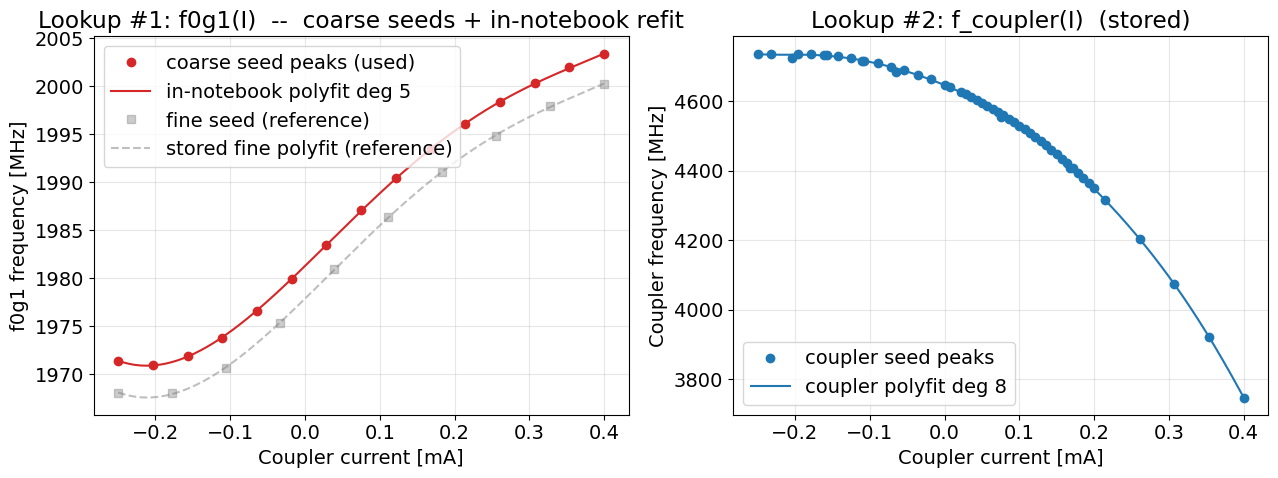

In [4]:
I_dense = np.linspace(LOOKUP_I_MIN, LOOKUP_I_MAX, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# f0g1: coarse seed (used) + in-notebook fit (used) + fine for reference.
axes[0].plot(f0g1_coarse_seed_I_mA, f0g1_coarse_seed_peaks, 'o', color='C3',
             label='coarse seed peaks (used)')
axes[0].plot(I_dense, f0g1_func(I_dense), '-', color='C3',
             label=f'in-notebook polyfit deg {F0G1_FIT_DEG}')
axes[0].plot(f0g1_fine_seed_I_mA, f0g1_fine_seed_peaks, 's', color='gray',
             alpha=0.4, label='fine seed (reference)')
axes[0].plot(I_dense, f0g1_fine_func(I_dense), '--', color='gray', alpha=0.5,
             label='stored fine polyfit (reference)')
axes[0].set_xlabel('Coupler current [mA]')
axes[0].set_ylabel('f0g1 frequency [MHz]')
axes[0].set_title('Lookup #1: f0g1(I)  --  coarse seeds + in-notebook refit')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(coupler_seed_I_mA, coupler_seed_peaks, 'o', color='C0',
             label='coupler seed peaks')
axes[1].plot(I_dense, f_coupler_func(I_dense), '-', color='C0',
             label=f'coupler polyfit deg {COUPLER_DEG}')
axes[1].set_xlabel('Coupler current [mA]')
axes[1].set_ylabel('Coupler frequency [MHz]')
axes[1].set_title('Lookup #2: f_coupler(I)  (stored)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Sweep parameters and current-to-flux conversion

**Set point + span + resolution** define a narrow current window around the operating point. The **flux anchors** come from `coupler_lookup_report.md` §2 (Φ/Φ₀=0 at I=−0.21 mA, Φ/Φ₀=0.5 at I=+0.75 mA → 1Φ₀ ≈ 1.92 mA). `PHI0_PER_MA` is *derived* from those two anchor currents so flipping anchors flips the conversion coherently.

In [5]:
# Flux anchors (from coupler_lookup_report.md §2). Single source of truth.
I_PHI0_MA     = -0.21   # current at Φ/Φ₀ = 0
I_PHI_HALF_MA = +0.75   # current at Φ/Φ₀ = 0.5

PHI0_PER_MA = 0.5 / (I_PHI_HALF_MA - I_PHI0_MA)   # → 1/1.92 Φ₀/mA

def current_to_flux(I_mA):
    """Convert Yoko-coupler current [mA] to flux [Φ₀] using the report's anchors."""
    return (np.asarray(I_mA, dtype=float) - I_PHI0_MA) * PHI0_PER_MA

def flux_to_current(phi):
    """Inverse of current_to_flux."""
    return I_PHI0_MA + np.asarray(phi, dtype=float) / PHI0_PER_MA


def make_sweep_grid(set_point, span, npts, units='mA', reverse=False):
    """Build a (set point, span, npts) grid in either current or flux units.

    Returns (currents_mA, fluxes_phi0, summary_dict). The current grid is what gets
    passed to the runners; the flux grid is for plotting and for round-trip
    serialization in the results pickle.

    units='mA'   -> set_point/span are in mA, current grid linspaced directly.
    units='phi0' -> set_point/span are in Φ₀, flux grid linspaced directly and
                    inverse-mapped to current via flux_to_current().
    reverse=False (default) -> currents_mA and fluxes_phi0 are in ascending order.
    reverse=True  -> currents_mA and fluxes_phi0 are in descending order (for
                    hysteresis checks).
    """
    if units == 'mA':
        currents = np.linspace(set_point - span / 2, set_point + span / 2, npts)
        if reverse:
            currents = currents[::-1]
        fluxes   = current_to_flux(currents)
        I_setpt, I_spanpt = float(set_point), float(span)
        phi_setpt = float(current_to_flux(set_point))
        phi_spanpt = float(current_to_flux(set_point + span / 2)
                           - current_to_flux(set_point - span / 2))            
    elif units == 'phi0':
        fluxes   = np.linspace(set_point - span / 2, set_point + span / 2, npts)
        if reverse:
            fluxes = fluxes[::-1]
        currents = flux_to_current(fluxes)
        phi_setpt, phi_spanpt = float(set_point), float(span)
        I_setpt = float(flux_to_current(set_point))
        I_spanpt = float(flux_to_current(set_point + span / 2)
                         - flux_to_current(set_point - span / 2))
    else:
        raise ValueError(f"units must be 'mA' or 'phi0', got {units!r}")

    return np.asarray(currents, dtype=float), np.asarray(fluxes, dtype=float), {
        'units_in':       units,
        'I_set_mA':       I_setpt,
        'I_span_mA':      I_spanpt,
        'phi_set_phi0':   phi_setpt,
        'phi_span_phi0':  phi_spanpt,
        'npts':           int(npts),
    }


# ---------------------------------------------------------------------------
# Choose ONE block. The wrapper handles the unit conversion both ways.
# ---------------------------------------------------------------------------

# A) Specify in current units (default; same as the parent notebook):
SWEEP_UNITS = 'mA'
SET_POINT   = -0.05        # mA
SPAN        = 0.001      # mA
I_npts      = 4           # resolution

# B) Or specify in flux units -- uncomment to use:
# SWEEP_UNITS = 'phi0'
# SET_POINT   = 0.266      # Φ₀  (≈ current_to_flux(0.30))
# SPAN        = 0.0026     # Φ₀  (≈ 0.005 mA)
# I_npts      = 4

currents_mA, fluxes_phi0, sweep_summary = make_sweep_grid(
    SET_POINT, SPAN, I_npts, units=SWEEP_UNITS, reverse=True)

# Promote to top-level names so the rest of the notebook is unchanged.
I_set_mA      = sweep_summary['I_set_mA']
I_span_mA     = sweep_summary['I_span_mA']
phi_set_phi0  = sweep_summary['phi_set_phi0']
phi_span_phi0 = sweep_summary['phi_span_phi0']

print(f'Sweep specified in {SWEEP_UNITS!r}.')
print(f'  set point: {I_set_mA:+.4f} mA  =  {phi_set_phi0:+.4f} Φ₀')
print(f'  span:      {I_span_mA:.4f} mA   =  {phi_span_phi0:.4f} Φ₀')
print(f'  resolution: {I_span_mA / (I_npts - 1):.4f} mA   =  {phi_span_phi0 / (I_npts - 1):.4f} Φ₀')
print(f'  currents [mA]: {currents_mA}')
print(f'  fluxes [Φ₀]:   {fluxes_phi0}')
print(f'  f0g1_func(I_set)      = {float(f0g1_func(I_set_mA)):.4f} MHz')
print(f'  f_coupler_func(I_set) = {float(f_coupler_func(I_set_mA)):.4f} MHz')

# Soft range guard (warn but don't abort -- operators may extrapolate intentionally).
if currents_mA.min() < LOOKUP_I_MIN or currents_mA.max() > LOOKUP_I_MAX:
    print('\n[WARN] Sweep extends outside the lookup calibration window '
          f'[{LOOKUP_I_MIN:.4f}, {LOOKUP_I_MAX:.4f}] mA. '
          'Polynomial extrapolation may be unreliable.')


Sweep specified in 'mA'.
  set point: -0.0500 mA  =  +0.0833 Φ₀
  span:      0.0010 mA   =  0.0005 Φ₀
  resolution: 0.0003 mA   =  0.0002 Φ₀
  currents [mA]: [-0.0495     -0.04983333 -0.05016667 -0.0505    ]
  fluxes [Φ₀]:   [0.08359375 0.08342014 0.08324653 0.08307292]
  f0g1_func(I_set)      = 1977.6318 MHz
  f_coupler_func(I_set) = 4685.8066 MHz


In [6]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # add the active reset dict to the expt config so that it can be used in the postprocessor
    
    return expt_cfg



def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')


Job submitted: JOB-20260610-00283 (queue position: 1)

[0.0s] Job JOB-20260610-00283: pending

[2.0s] Job JOB-20260610-00283: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260610-00283_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.05mA according to expt.cfg...
[WORKER] Done setting coupler current
 66%|████████████████████████████████████████████████████████▎                             | 3276/5000 [00:06<00:03, 498.90it/s]
[22.3s] Job JOB-20260610-00283: completed
100%|██████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 498.90it/s]
Unrotated:
Ig -89.21081081081081 +/- 29.739011437217926 	 Qg -62.22297297297297 +/- 26.10912830146378 	 Amp g 108.76703145309062
Ie 7.4135135135135135 +/- 33.07159335669488 	 Qe -64.7945945945946 +/- 25.984736099538825 	 Amp e 65.217326465387

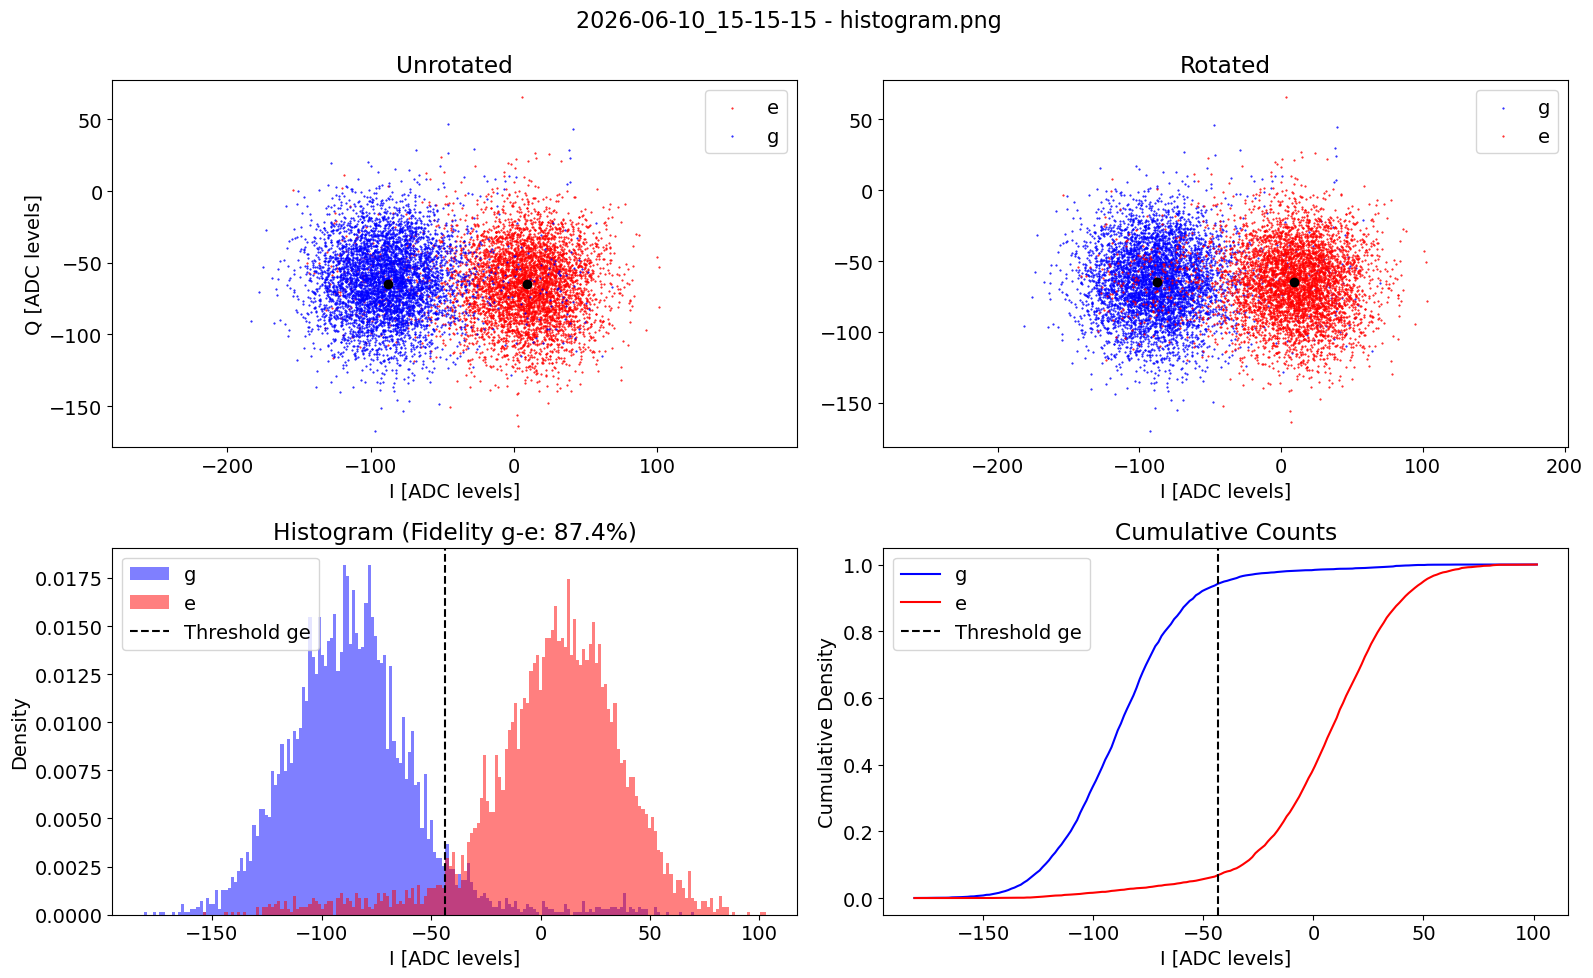

In [7]:
single_shot_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

single_shot = single_shot_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2000,
        pre_sweep_pulse=None,
        prepulse=False,
        gate_based=False,
        reps=5000,
        coupler_current=float(I_set_mA * 1e-3), 
    )

## Step 2 — Baseline f0g1 vs flux (no Stark drive)

Drive-off reference for `df0g1/dI`. Inner experiment: `meas.PulseProbeF0g1SpectroscopyExperiment`. At each current point we pass `f0g1_freq=f0g1_fine_func(I)` so the readout pi pulse stays calibrated as the coupler tunes (per-call override, commit 23f46af). The probe `start` is set to `None` so `qspec_preproc` auto-centers on the override frequency.

In [67]:
f0g1_spec_defaults = AttrDict(dict(
    man_mode_no=1,
    start=None,           # auto-center on calibrated f0g1 (override)
    step=0.15,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,
    qubits=[0],
    transition=None,
    relax_delay=200,
    active_reset=False,
    prepulse=False,
    pre_sweep_pulse=None,
))


def qspec_preproc(station, default_expt_cfg, **kwargs):
    """Insert |f⟩ prep before the probe and auto-center on the per-call f0g1 freq."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])
        pre_sweep_pulse = mm_base_calib.prep_man_photon(
            man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', f'g{i}-e{i}', 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', f'e{i}-f{i}', 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(
            pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

    if expt_cfg.start is None:
        band = expt_cfg.step * expt_cfg.expts / 2
        # Per-call override beats the hardware_cfg if present.
        if 'f0g1_freq' in expt_cfg and expt_cfg.f0g1_freq is not None:
            center = float(expt_cfg.f0g1_freq)
        else:
            center = station.hardware_cfg.device.multiphoton['pi'][
                expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx]
        expt_cfg.start = center - band

    return expt_cfg


In [68]:
def do_f0g1_current_sweep_with_lookup(
    station,
    currents_mA,                 # sweep grid in mA (assumed to be inside the safety check)
    f0g1_func,              # callable: I_mA -> f0g1 [MHz]
    live_plot=True,
    safety_mA=1.0,
    **kwargs,                    # override f0g1_spec_defaults
):
    """Baseline f0g1-vs-flux with per-current f0g1_freq retune from lookup."""
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(f0g1_spec_defaults)))
    expt_cfg.update(kwargs)

    currents_mA = np.asarray(currents_mA, dtype=float)
    assert np.max(np.abs(currents_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(currents_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
        default_expt_cfg=expt_cfg,
        preprocessor=qspec_preproc,
        job_client=client,
    )

    mother_expt = meas.PulseProbeF0g1SpectroscopyExperiment(
        soccfg=station.soccfg,
        path=station.data_path,
        prefix='PulseProbeF0g1Spectroscopy_baseline_lookup_currentsweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {
        'coupler_current_sweep_mA': [],
        'f0g1_used_MHz': [],
    }

    print(f'Baseline f0g1 sweep: {len(currents_mA)} points, '
          f'I in [{currents_mA.min():.4f}, {currents_mA.max():.4f}] mA')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(currents_mA):
        f0g1_here = float(f0g1_func(float(i_mA)))
        print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA  '
              f'f0g1 = {f0g1_here:.3f} MHz')
        expt = runner.run(
            postprocess=False,
            log=False,
            coupler_current=float(i_mA * 1e-3),
            f0g1_freq=f0g1_here,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        mother_expt.data['f0g1_used_MHz'].append(f0g1_here)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs_2d = np.asarray(mother_expt.data['xpts'])
            sig = np.asarray(mother_expt.data['avgi'])
            f0g1_used = np.asarray(mother_expt.data['f0g1_used_MHz'])
            detuning_2d = freqs_2d - f0g1_used[:, None]
            detuning_axis = detuning_2d[0]
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(detuning_axis, currents_so_far, sig,
                                shading='nearest', cmap='viridis')
            ax.set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax2 = ax.secondary_yaxis('right',
                                     functions=(current_to_flux, flux_to_current))
            ax2.set_ylabel(r'Flux  $\Phi/\Phi_0$')
            ax.set_title('Baseline f0g1 spec vs DC flux (live, lookup-retuned)')
            fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
            plt.tight_layout()
            plt.show()

    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt


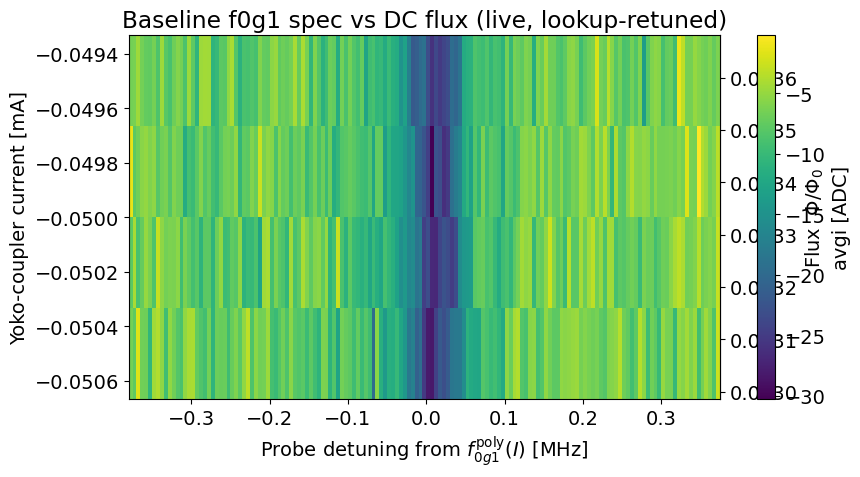

Saving D:\experiments\260420_T2_AC_stark\data\00020_PulseProbeF0g1Spectroscopy_baseline_lookup_currentsweep.h5
Complete. Saved to D:\experiments\260420_T2_AC_stark\data\00020_PulseProbeF0g1Spectroscopy_baseline_lookup_currentsweep.h5


In [69]:
f0g1_baseline = do_f0g1_current_sweep_with_lookup(
    station,
    currents_mA=currents_mA,
    f0g1_func=f0g1_func,
    live_plot=True,
    transition='f0-g1',
    start=None,                # auto-center on f0g1_freq override
    step=0.005, expts=151,
    gain=100, length=20.0,
    reps=500,
    # reps=100,
      rounds=1,
)


Baseline df0g1/dI = 70.8058 MHz/mA   (intercept 1981.182 MHz)


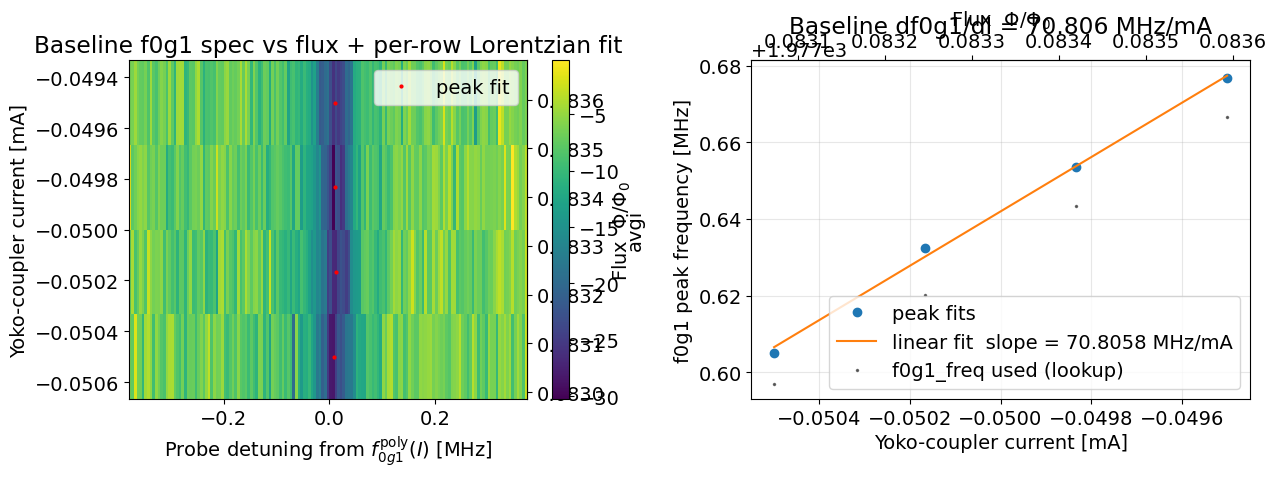

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\QEC\2026\05\2026-05-15.md


WindowsPath('H:/Shared drives/SLab/Multimode/Lab/seb/QEC/2026/05/2026-05-15.md')

In [70]:
FIT_CHANNEL = 'avgi'
FIT_SIGN    = 1

baseline_currents_mA = np.asarray(f0g1_baseline.data['coupler_current_sweep_mA'])
baseline_f0g1_used   = np.asarray(f0g1_baseline.data['f0g1_used_MHz'])
baseline_freqs_2d   = np.asarray(f0g1_baseline.data['xpts'])
baseline_freqs_MHz  = baseline_freqs_2d[0]   # axis used only for the static-window pcolormesh fallback
baseline_sig_2d      = np.asarray(f0g1_baseline.data[FIT_CHANNEL])

peaks_baseline = fit_peak_per_row(baseline_freqs_2d, np.abs(baseline_sig_2d), sign=FIT_SIGN)
slope_baseline, intercept_baseline = linear_sensitivity(baseline_currents_mA, peaks_baseline)
print(f'Baseline df0g1/dI = {slope_baseline:.4f} MHz/mA   '
      f'(intercept {intercept_baseline:.3f} MHz)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Detuning grid is identical row-to-row by construction (each row sweeps f0g1_used[i] +- band).
# Use 1D axes so pcolormesh cell positions are unambiguous.
baseline_detuning_2d = baseline_freqs_2d - baseline_f0g1_used[:, None]
baseline_detuning_axis = baseline_detuning_2d[0]
pcm = axes[0].pcolormesh(baseline_detuning_axis, baseline_currents_mA, baseline_sig_2d,
                         shading='nearest', cmap='viridis')
axes[0].plot(peaks_baseline - baseline_f0g1_used, baseline_currents_mA,
             'r.', ms=4, label='peak fit')
axes[0].set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
axes[0].set_ylabel('Yoko-coupler current [mA]')
axes[0].set_title('Baseline f0g1 spec vs flux + per-row Lorentzian fit')
axes[0].legend(loc='best')
axes[0].secondary_yaxis('right', functions=(current_to_flux, flux_to_current)).set_ylabel(
    r'Flux  $\Phi/\Phi_0$')
fig.colorbar(pcm, ax=axes[0], label=FIT_CHANNEL)

I_dense = np.linspace(baseline_currents_mA.min(), baseline_currents_mA.max(), 200)
axes[1].plot(baseline_currents_mA, peaks_baseline, 'o', label='peak fits')
axes[1].plot(I_dense, slope_baseline * I_dense + intercept_baseline, '-',
             label=f'linear fit  slope = {slope_baseline:.4f} MHz/mA')
axes[1].plot(baseline_currents_mA, baseline_f0g1_used, 'k.', ms=3, alpha=0.5,
             label='f0g1_freq used (lookup)')
axes[1].set_xlabel('Yoko-coupler current [mA]')
axes[1].set_ylabel('f0g1 peak frequency [MHz]')
axes[1].set_title(f'Baseline df0g1/dI = {slope_baseline:.3f} MHz/mA')
axes[1].secondary_xaxis('top', functions=(current_to_flux, flux_to_current)).set_xlabel(
    r'Flux  $\Phi/\Phi_0$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Lab-notebook entry for the baseline 2D map.
station.log_measurement(
    fig=fig,
    title='Baseline f0g1 vs flux (Step 2, lookup-driven, no Stark)',
    project='QEC',
    parameters={
        'I_set_mA':                  float(I_set_mA),
        'I_span_mA':                 float(I_span_mA),
        'phi_set_phi0':              float(phi_set_phi0),
        'phi_span_phi0':             float(phi_span_phi0),
        'I_npts':                    int(I_npts),
        'fit_channel':               FIT_CHANNEL,
        'fit_sign':                  FIT_SIGN,
        'slope_baseline_MHz_per_mA': float(slope_baseline),
        'intercept_baseline_MHz':    float(intercept_baseline),
        'f0g1_poly_coeffs':          list(map(float, f0g1_func.coefficients)),
        'f0g1_fit_deg':              int(F0G1_FIT_DEG),
        'f0g1_seed_source':          'f0g1_coarse',
        'lookup_pickle_path':        str(LOOKUP_PATH),
        'lookup_pickle_mtime':       float(os.path.getmtime(LOOKUP_PATH)),
        'flux_anchors': {
            'I_PHI0_MA':     float(I_PHI0_MA),
            'I_PHI_HALF_MA': float(I_PHI_HALF_MA),
            'PHI0_PER_MA':   float(PHI0_PER_MA),
        },
    },
    data_path=f0g1_baseline.fname,
    notes=('Baseline (Stark off) f0g1 spectroscopy vs flux. '
           'f0g1_freq retuned per current via f0g1_func, an in-notebook polyfit on the '
           "lookup pickle's coarse f0g1 seed peaks."),
)


## Step 3 — Single-detuning Stark sweep with fixed drive frequency (flavor of Step 2)

Like Step 2 (per-current `f0g1_freq` retune from the lookup), but with the Stark drive turned on. Crucially the drive frequency does **not** track the coupler across the current sweep — it is locked at `f_coupler_func(I_set_mA) + Δ` for every current point, so as the coupler tunes with `I` the effective drive→coupler detuning changes slightly across the span.

This isolates the Stark contribution to `df0g1/dI` when the drive is *not* compensated as the coupler drifts, in contrast with Step 4 which scans many Δ at constant detuning (drive retuned per current point).

The Stark-drive setup below (defaults, Ω₀-based `DRIVE_GAIN` suggestion, envelope timing) is shared with Step 4.

In [59]:
f0g1_stark_defaults = AttrDict(dict(
    # f0g1 probe (same conventions as the multiphoton calibration).
    man_mode_no=1,
    start=None,                  # auto-center on f0g1_freq override
    step=0.025,
    expts=151,
    reps=500,
    rounds=1,
    length=20.0,
    gain=100,
    pulse_type='gaussian',
    qubit_f=False,
    qubits=[0],
    transition=None,
    relax_delay=200,
    active_reset=False,
    prepulse=False,
    pre_sweep_pulse=None,
    # Stark drive (drive_freq set per current point by the helper).
    drive_freq=4095.0,           # placeholder; overridden per point
    drive_gain=2000,
    rise_time=0.1,
    stark_guard_pre=1.0,
    stark_guard_post=1.0,
    drive_hold_margin=5.0,
))


### Suggest `drive_gain` from a target Rabi rate

Inverts the per-current Rabi-gain calibration `k_per_DAC` from the lookup pickle. Two formulas depending on the regime in which `k` was extracted (see `coupler_lookup_analysis.ipynb` §2):

- **long_T2** (amp-Rabi sin fit) — `k` is cycles/DAC at calibration pulse `t_eff_us`. → `Ω_MHz = k · gain / t_eff_us`.
- **short_T2** (spec-vs-power) — `k` is MHz/DAC directly. → `Ω_MHz = k · gain`.

Both expose the inverse so you can pick a `DRIVE_GAIN` for a target `Ω_Rabi`.

In [11]:
def _round_key(I_mA, decimals=4):
    """Stable float key for the per-current characterization dict.

    Mirrors `_round_key` from coupler_systematic_study_v2.ipynb so we can find
    the same per-current entries that were saved by the systematic-study run.
    """
    return float(np.round(float(I_mA) + 0.0, decimals))


def get_rabi_calibration_at(I_mA, *, lookup=None):
    """Look up `k_per_DAC` + regime + `t_eff_us` at the closest characterized current.

    The systematic-study lookup pickle stores per-current characterization in
    `lookup['characterization'][I_rounded]`. Each entry carries:
      - `'k_per_DAC'` [float, MHz/DAC]: Rabi-frequency-per-DAC. Same units in
          BOTH regimes (long_T2 normalizes the cycles/DAC sin-fit by t_eff_us;
          short_T2 Torrey fit reports it natively). Operational relation:
              Ω_R/(2π) [MHz] = k * gain     (population Rabi frequency)
          In the user's Hamiltonian convention HR = ... + Ω0*(b + b†),
              Ω0/(2π) [MHz]   = k * gain / 2
      - `'regime'` [str]
      - `'rabi'` [dict, optional]: holds `'t_eff_us'`, `'pi_gain'`, etc.
    """
    if lookup is None:
        lookup = lookup_on_disk
    char = lookup.get('characterization', {})
    if not char:
        raise KeyError("No 'characterization' dict in lookup pickle.")

    target = _round_key(I_mA)
    nearest = min(char.keys(), key=lambda x: abs(float(x) - target))
    entry = char[nearest]

    rabi_sub = entry.get('rabi') or {}
    k = entry.get('k_per_DAC', float('nan'))
    return {
        'I_lookup_mA': float(nearest),
        'I_offset_mA': float(nearest) - float(I_mA),
        'k_per_DAC':   float(k) if k == k else float('nan'),
        'regime':      entry.get('regime', '?'),
        't_eff_us':    (float(rabi_sub['t_eff_us'])
                        if rabi_sub.get('t_eff_us') is not None else None),
        'pi_gain':     (float(rabi_sub['pi_gain'])
                        if rabi_sub.get('pi_gain') is not None else None),
    }


def suggest_drive_gain(target_Omega0_MHz, k_per_DAC, *, t_eff_us=None, regime=None):
    """Inverse calibration: target Ω0/(2π) [MHz] -> drive_gain [DAC units].

    Convention used throughout this notebook (the user's, not the standard):
        HR = ... + Ω0*(b + b†)     [no 1/2 factor]
    so the Hamiltonian coefficient Ω0 is HALF the population Rabi frequency:
        Ω_R = 2*Ω0.

    The pickle's `k_per_DAC` is stored in MHz/DAC for BOTH regimes and equals
    Ω_R/(2π) per DAC unit. Hence:
        Ω_R/(2π) [MHz]   = k * gain       (regime-agnostic)
        Ω0/(2π) [MHz]    = k * gain / 2   (user's convention)
    => gain = 2 * target_Omega0_MHz / k_per_DAC.

    `t_eff_us` and `regime` are accepted for backward compatibility but ignored:
    after the producer fix in coupler_systematic_study.ipynb the stored k is in
    MHz/DAC for both regimes, so no t_eff division is needed.
    """
    return int(round(2.0 * float(target_Omega0_MHz) / float(k_per_DAC)))


# --- Print a suggestion at the operating set point ---
# TARGET_OMEGA0_MHz is Ω0/(2π) in the user's Hamiltonian convention
# HR = ... + Ω0*(b + b†). Population Rabi frequency Ω_R = 2*Ω0.
TARGET_OMEGA0_MHz = .1   # target Stark-drive Ω0/(2π) [MHz]

cal = get_rabi_calibration_at(I_set_mA)
print(f'Calibration at I = {cal["I_lookup_mA"]:+.4f} mA '
      f'(offset {cal["I_offset_mA"]:+.4f} mA from setpoint {I_set_mA:+.4f}):')
print(f'  regime    = {cal["regime"]}')
print(f'  k_per_DAC = {cal["k_per_DAC"]:.3e} MHz/DAC')
print(f'  t_eff_us  = {cal["t_eff_us"]}')
print(f'  pi_gain   = {cal["pi_gain"]}')

if np.isfinite(cal['k_per_DAC']):
    SUGGESTED_DRIVE_GAIN = suggest_drive_gain(
        TARGET_OMEGA0_MHz, cal['k_per_DAC'])
    print(f'\nFor target Ω0/(2π) = {TARGET_OMEGA0_MHz:.3f} MHz: '
          f'SUGGESTED_DRIVE_GAIN = {SUGGESTED_DRIVE_GAIN}')
else:
    SUGGESTED_DRIVE_GAIN = None
    print('\n[WARN] No k_per_DAC at this current; SUGGESTED_DRIVE_GAIN = None. '
          'Set DRIVE_GAIN manually in the next cell.')


Calibration at I = -0.0500 mA (offset +0.0000 mA from setpoint -0.0500):
  regime    = long_T2
  k_per_DAC = 4.022e-04 MHz/DAC
  t_eff_us  = 0.061745697353369516
  pi_gain   = 20115.184214866928

For target Ω0/(2π) = 0.100 MHz: SUGGESTED_DRIVE_GAIN = 497


In [12]:
# Stark drive amplitude (shared by Step 3 and Step 4). Defaults to the suggestion
# from suggest_drive_gain above (set via TARGET_OMEGA0_MHz). To override, comment
# the SUGGESTED_DRIVE_GAIN line and assign DRIVE_GAIN directly.
DRIVE_GAIN = SUGGESTED_DRIVE_GAIN if SUGGESTED_DRIVE_GAIN is not None else 30000
# DRIVE_GAIN = 30000   # uncomment to override the suggestion

# Stark drive envelope timing (cfg.expt fields read in
# pulse_probe_f0g1_spectroscopy_stark.py:69-115). Shared by Step 3 and Step 4.
RISE_TIME          = 2.4     # us  -- rise/fall length of the long-pulse envelope
STARK_GUARD_PRE    = 20.0    # us  -- gap between rise end and first probe pulse
STARK_GUARD_POST   = 1.0     # us  -- gap between readout end and fall start
DRIVE_HOLD_MARGIN  = 5.0     # us  -- extra const-portion length over the auto-estimate

print(f'DRIVE_GAIN = {DRIVE_GAIN}  '
      f'(target Ω0/(2π) {TARGET_OMEGA0_MHz:.3f} MHz, regime {cal["regime"]}, '
      f'k_per_DAC = {cal["k_per_DAC"]:.3e} MHz/DAC)')


DRIVE_GAIN = 497  (target Ω0/(2π) 0.100 MHz, regime long_T2, k_per_DAC = 4.022e-04 MHz/DAC)


In [13]:
def do_f0g1_stark_current_sweep_fixed_drive(
    station,
    detuning_MHz,
    I_anchor_mA,                 # current at which the drive freq is locked
    f_coupler_func,              # callable: I_mA -> f_coupler [MHz]
    f0g1_func,                   # callable: I_mA -> f0g1 [MHz]
    currents_mA,                 # sweep grid in mA
    live_plot=True,
    safety_mA=1.0,
    **kwargs,                    # override f0g1_stark_defaults
):
    """f0g1 spec vs flux with Stark drive locked to f_coupler(I_anchor) + det.

    Variant of `do_f0g1_stark_current_sweep_at_detuning_with_lookup` where
    `drive_freq` is fixed at `f_coupler_func(I_anchor) - detuning_MHz` for
    (convention: detuning = f_coupler - drive_freq).
    every current point (no per-current retune of the drive). `f0g1_freq` is
    still retuned per current via `f0g1_func` so the readout pi stays calibrated.
    """
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(f0g1_stark_defaults)))
    expt_cfg.update(kwargs)

    currents_mA = np.asarray(currents_mA, dtype=float)
    assert np.max(np.abs(currents_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(currents_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    # Convention: detuning_MHz = f_coupler - drive_freq, so drive = coupler - detuning.
    drive_freq_fixed = float(f_coupler_func(float(I_anchor_mA)) - detuning_MHz)

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeF0g1StarkAlwaysOnExperiment,
        default_expt_cfg=expt_cfg,
        preprocessor=qspec_preproc,
        job_client=client,
    )

    mother_expt = meas.PulseProbeF0g1StarkAlwaysOnExperiment(
        soccfg=station.soccfg,
        path=station.data_path,
        prefix=f'PulseProbeF0g1StarkAlwaysOn_fixedDrive_det{detuning_MHz:+.2f}MHz_currentsweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {
        'coupler_current_sweep_mA': [],
        'drive_freq_fixed_MHz':     drive_freq_fixed,
        'I_anchor_mA':              float(I_anchor_mA),
        'f0g1_used_MHz':            [],
        'detuning_MHz':             float(detuning_MHz),
    }

    print(f'Fixed-drive Stark sweep at det {detuning_MHz:+.3f} MHz, anchor I = '
          f'{I_anchor_mA:+.4f} mA  ->  drive_freq = {drive_freq_fixed:.3f} MHz')
    print(f'  {len(currents_mA)} points, I in '
          f'[{currents_mA.min():.4f}, {currents_mA.max():.4f}] mA')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(currents_mA):
        f0g1_here = float(f0g1_func(float(i_mA)))
        print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA  '
              f'f0g1 = {f0g1_here:.3f} MHz  (drive fixed @ {drive_freq_fixed:.3f} MHz)')
        expt = runner.run(
            postprocess=False,
            log=False,
            coupler_current=float(i_mA * 1e-3),
            drive_freq=drive_freq_fixed,
            f0g1_freq=f0g1_here,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        mother_expt.data['f0g1_used_MHz'].append(f0g1_here)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs_2d = np.asarray(mother_expt.data['xpts'])
            sig = np.asarray(mother_expt.data['avgi'])
            f0g1_used = np.asarray(mother_expt.data['f0g1_used_MHz'])
            detuning_2d = freqs_2d - f0g1_used[:, None]
            detuning_axis = detuning_2d[0]
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(detuning_axis, currents_so_far, sig,
                                shading='nearest', cmap='viridis')
            ax.set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.secondary_yaxis('right',
                               functions=(current_to_flux, flux_to_current)).set_ylabel(
                r'Flux  $\Phi/\Phi_0$')
            ax.set_title(f'f0g1 vs flux, fixed Stark drive @ {drive_freq_fixed:.2f} MHz '
                         f'(det {detuning_MHz:+.2f} MHz @ I={I_anchor_mA:+.4f} mA)')
            # shift a colorbar further right to avoid crowding the secondary y-axis labels
            fig.colorbar(pcm, ax=ax, label='avgi [ADC]', pad=0.2)
            plt.tight_layout()
            plt.show()

    mother_expt.data = {
        k: (np.array(v) if isinstance(v, list) else v)
        for k, v in mother_expt.data.items()
    }
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt


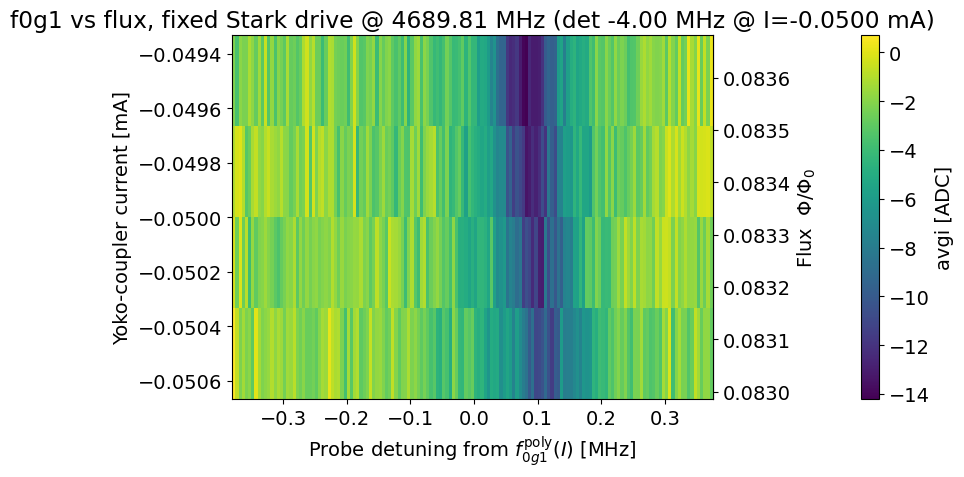

Saving D:\experiments\260420_T2_AC_stark\data\00021_PulseProbeF0g1StarkAlwaysOn_fixedDrive_det-4.00MHz_currentsweep.h5
Complete. Saved to D:\experiments\260420_T2_AC_stark\data\00021_PulseProbeF0g1StarkAlwaysOn_fixedDrive_det-4.00MHz_currentsweep.h5


In [65]:
# Single-detuning fixed-drive run.
# Drive frequency is locked to f_coupler_func(I_set_mA) + FIXED_DETUNING_MHz
# for every current point; only f0g1_freq is retuned per current via f0g1_func.
FIXED_DETUNING_MHz = -4.0   # MHz, drive offset from f_coupler(I_set)

f0g1_fixed_drive = do_f0g1_stark_current_sweep_fixed_drive(
    station,
    detuning_MHz=FIXED_DETUNING_MHz,
    I_anchor_mA=I_set_mA,
    f_coupler_func=f_coupler_func,
    f0g1_func=f0g1_func,
    currents_mA=currents_mA,
    live_plot=True,
    transition='f0-g1',
    drive_gain=DRIVE_GAIN,
    rise_time=RISE_TIME,
    stark_guard_pre=STARK_GUARD_PRE,
    stark_guard_post=STARK_GUARD_POST,
    drive_hold_margin=DRIVE_HOLD_MARGIN,
    start=None,
    step=0.005, expts=151,
    gain=100, length=20.0,
    reps=2500,
    rounds=1,
)


Fixed-drive df0g1/dI = +42.6561 MHz/mA  (= +81.8997 MHz/Φ₀), with drive @ 4689.807 MHz
  intercepts: 1979.859 MHz @ I=0   |   1970.901 MHz @ Φ=0   |   drive @ 4689.807 MHz
  drive-coupler resonance: I = -0.0561 mA  (Φ = +0.0801 Φ₀) → f0g1 = 1977.210 MHz


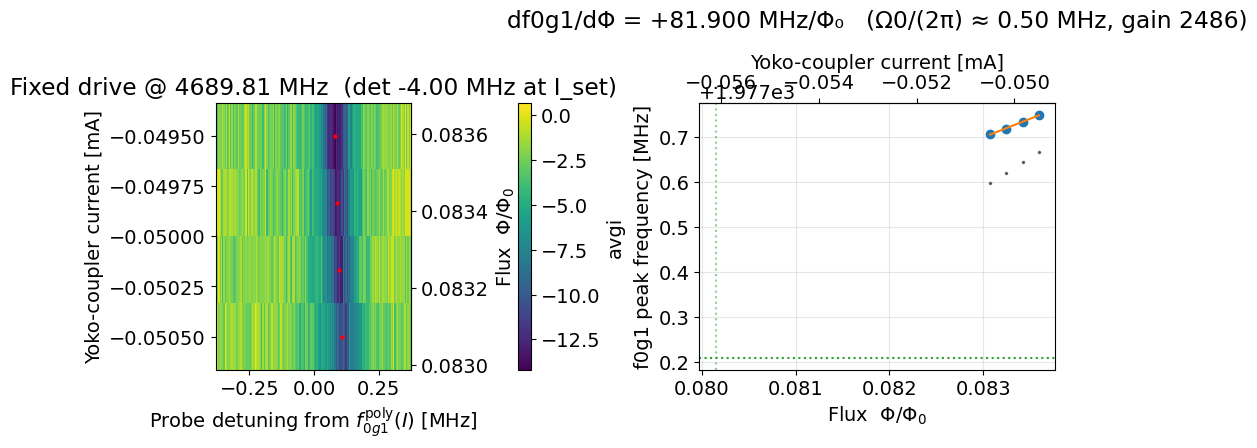

[log_measurement] Appended section to H:\Shared drives\SLab\Multimode\Lab\seb\QEC\2026\05\2026-05-15.md


WindowsPath('H:/Shared drives/SLab/Multimode/Lab/seb/QEC/2026/05/2026-05-15.md')

In [66]:
FIT_CHANNEL = 'avgi'
FIT_SIGN    = 1

fixed_drive_currents_mA = np.asarray(f0g1_fixed_drive.data['coupler_current_sweep_mA'])
fixed_drive_f0g1_used   = np.asarray(f0g1_fixed_drive.data['f0g1_used_MHz'])
fixed_drive_freqs_2d    = np.asarray(f0g1_fixed_drive.data['xpts'])
fixed_drive_sig_2d      = np.asarray(f0g1_fixed_drive.data[FIT_CHANNEL])
fixed_drive_freq_MHz    = float(f0g1_fixed_drive.data['drive_freq_fixed_MHz'])

peaks_fixed_drive = fit_peak_per_row(
    fixed_drive_freqs_2d, np.abs(fixed_drive_sig_2d), sign=FIT_SIGN)

# mA-basis fit (kept for logging compatibility with old runs).
slope_fixed_drive, intercept_fixed_drive = linear_sensitivity(
    fixed_drive_currents_mA, peaks_fixed_drive)

# Φ₀-basis fit: refit directly so the intercept matches the Φ₀ x-axis.
# (Just transforming intercept_mA would be wrong because current_to_flux has
#  an offset I_PHI0_MA, so Φ=0 ≠ I=0.)
fixed_drive_flux_phi0 = current_to_flux(fixed_drive_currents_mA)
slope_fixed_drive_per_phi0, intercept_fixed_drive_phi0 = linear_sensitivity(
    fixed_drive_flux_phi0, peaks_fixed_drive)

# --- f0g1 frequency at which the Stark drive is resonant with the coupler ---
# Solve f_coupler_func(I) = fixed_drive_freq_MHz, then evaluate f0g1_func there.
_coupler_roots = (f_coupler_func - fixed_drive_freq_MHz).roots
_real_roots = _coupler_roots[np.abs(_coupler_roots.imag) < 1e-6].real
if _real_roots.size:
    _I_mid = fixed_drive_currents_mA.mean()
    I_drive_resonant_mA = float(_real_roots[np.argmin(np.abs(_real_roots - _I_mid))])
    phi_drive_resonant  = float(current_to_flux(I_drive_resonant_mA))
    f0g1_at_drive_resonance_MHz = float(f0g1_func(I_drive_resonant_mA))
else:
    I_drive_resonant_mA = phi_drive_resonant = f0g1_at_drive_resonance_MHz = np.nan

print(f'Fixed-drive df0g1/dI = {slope_fixed_drive:+.4f} MHz/mA  '
      f'(= {slope_fixed_drive_per_phi0:+.4f} MHz/Φ₀), with drive @ {fixed_drive_freq_MHz:.3f} MHz')
print(f'  intercepts: {intercept_fixed_drive:.3f} MHz @ I=0   |   '
      f'{intercept_fixed_drive_phi0:.3f} MHz @ Φ=0   |   '
      f'drive @ {fixed_drive_freq_MHz:.3f} MHz')
print(f'  drive-coupler resonance: I = {I_drive_resonant_mA:.4f} mA  '
      f'(Φ = {phi_drive_resonant:+.4f} Φ₀) → f0g1 = {f0g1_at_drive_resonance_MHz:.3f} MHz')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fixed_drive_detuning_2d   = fixed_drive_freqs_2d - fixed_drive_f0g1_used[:, None]
fixed_drive_detuning_axis = fixed_drive_detuning_2d[0]
pcm = axes[0].pcolormesh(fixed_drive_detuning_axis, fixed_drive_currents_mA,
                         fixed_drive_sig_2d, shading='nearest', cmap='viridis')
axes[0].plot(peaks_fixed_drive - fixed_drive_f0g1_used, fixed_drive_currents_mA,
             'r.', ms=4, label='peak fit')
axes[0].set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
axes[0].set_ylabel('Yoko-coupler current [mA]')
axes[0].set_title(f'Fixed drive @ {fixed_drive_freq_MHz:.2f} MHz  '
                  f'(det {FIXED_DETUNING_MHz:+.2f} MHz at I_set)')
# axes[0].legend(loc='best')
axes[0].secondary_yaxis('right',
                        functions=(current_to_flux, flux_to_current)).set_ylabel(
    r'Flux  $\Phi/\Phi_0$')
fig.colorbar(pcm, ax=axes[0], label=FIT_CHANNEL, pad=0.3)

# ---- axes[1]: f0g1 peak vs flux (Φ₀ primary, mA secondary on top) ----
phi_dense = np.linspace(fixed_drive_flux_phi0.min(), fixed_drive_flux_phi0.max(), 200)
axes[1].plot(fixed_drive_flux_phi0, peaks_fixed_drive, 'o', label='peak fits')
axes[1].plot(phi_dense,
             slope_fixed_drive_per_phi0 * phi_dense + intercept_fixed_drive_phi0, '-')
axes[1].plot(fixed_drive_flux_phi0, fixed_drive_f0g1_used, 'k.', ms=3, alpha=0.5,
             label='f0g1_freq used (lookup)')
# # Stark drive frequency (helps visualize the detuning at each flux point).
# axes[1].axhline(fixed_drive_freq_MHz, color='r', ls='--',
#                 label=f'stark drive @ {fixed_drive_freq_MHz:.2f} MHz')
# f0g1 frequency at which the drive is resonant with the coupler:
# i.e. f0g1_func(I*) where f_coupler_func(I*) = fixed_drive_freq_MHz.
if np.isfinite(f0g1_at_drive_resonance_MHz):
    axes[1].axhline(f0g1_at_drive_resonance_MHz, color='C2', ls=':',
                    label=(f'f0g1 at drive↔coupler resonance '))
                        #    f'({f0g1_at_drive_resonance_MHz:.2f} MHz, '
                        #    f'Φ = {phi_drive_resonant:+.3f} Φ₀)'))
    axes[1].axvline(phi_drive_resonant, color='C2', ls=':', alpha=0.5)
axes[1].set_xlabel(r'Flux  $\Phi/\Phi_0$')
axes[1].set_ylabel('f0g1 peak frequency [MHz]')
Omega0_used_MHz = cal['k_per_DAC'] * DRIVE_GAIN / 2
axes[1].set_title(
    f'df0g1/dΦ = {slope_fixed_drive_per_phi0:+.3f} MHz/Φ₀   '
    f'(Ω0/(2π) ≈ {Omega0_used_MHz:.2f} MHz, gain {DRIVE_GAIN})',
    y=1.25,
)
axes[1].secondary_xaxis('top',
                        functions=(flux_to_current, current_to_flux)).set_xlabel(
    'Yoko-coupler current [mA]')
# axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

station.log_measurement(
    fig=fig,
    title=f'f0g1 vs flux at fixed Stark drive {fixed_drive_freq_MHz:.2f} MHz (Step 3, lookup-driven)',
    project='QEC',
    parameters={
        'fixed_detuning_MHz':                 float(FIXED_DETUNING_MHz),
        'detuning_convention':                'f_coupler_minus_drive',
        'drive_freq_fixed_MHz':               float(fixed_drive_freq_MHz),
        'I_anchor_mA':                        float(I_set_mA),
        'drive_gain':                         int(DRIVE_GAIN),
        'target_Omega0_MHz':                  float(TARGET_OMEGA0_MHz),
        'k_per_DAC':                          float(cal['k_per_DAC']),
        'k_regime':                           str(cal['regime']),
        'k_lookup_I_mA':                      float(cal['I_lookup_mA']),
        'rise_time_us':                       float(RISE_TIME),
        'stark_guard_pre_us':                 float(STARK_GUARD_PRE),
        'stark_guard_post_us':                float(STARK_GUARD_POST),
        'drive_hold_margin_us':               float(DRIVE_HOLD_MARGIN),
        'I_set_mA':                           float(I_set_mA),
        'I_span_mA':                          float(I_span_mA),
        'phi_set_phi0':                       float(phi_set_phi0),
        'phi_span_phi0':                      float(phi_span_phi0),
        'I_npts':                             int(I_npts),
        'fit_channel':                        FIT_CHANNEL,
        'fit_sign':                           FIT_SIGN,
        'slope_fixed_drive_MHz_per_mA':       float(slope_fixed_drive),
        'intercept_fixed_drive_MHz_at_I0':    float(intercept_fixed_drive),
        'slope_fixed_drive_MHz_per_phi0':     float(slope_fixed_drive_per_phi0),
        'intercept_fixed_drive_MHz_at_phi0':  float(intercept_fixed_drive_phi0),
        'I_drive_coupler_resonance_mA':       float(I_drive_resonant_mA),
        'phi_drive_coupler_resonance_phi0':   float(phi_drive_resonant),
        'f0g1_at_drive_coupler_resonance_MHz': float(f0g1_at_drive_resonance_MHz),
        'PHI0_PER_MA':                        float(PHI0_PER_MA),
        'I_PHI0_MA':                          float(I_PHI0_MA),
        'f0g1_poly_coeffs':                   list(map(float, f0g1_func.coefficients)),
        'f0g1_fit_deg':                       int(F0G1_FIT_DEG),
        'f0g1_seed_source':                   'f0g1_coarse',
        'f_coupler_poly_coeffs':              list(map(float, f_coupler_func.coefficients)),
        'lookup_pickle_path':                 str(LOOKUP_PATH),
        'lookup_pickle_mtime':                float(os.path.getmtime(LOOKUP_PATH)),
    },
    data_path=f0g1_fixed_drive.fname,
    notes=(f'Single-detuning Stark sweep with drive frequency LOCKED at '
           f'f_coupler(I_set) - {FIXED_DETUNING_MHz:+.2f} MHz = '
           f'{fixed_drive_freq_MHz:.3f} MHz '
           f'(convention: Δ = f_coupler − drive_freq). '
           'The drive does NOT track the coupler as I sweeps; only f0g1_freq is '
           'retuned per current.'),
)


In [ ]:
# ---- Extra figure: individual traces with Lorentzian fits ----
from scipy.optimize import curve_fit

N_TRACES = 6
trace_idx = np.linspace(0, len(fixed_drive_currents_mA) - 1, N_TRACES, dtype=int)

ncols = 3
nrows = int(np.ceil(N_TRACES / ncols))
fig_traces, ax_traces = plt.subplots(nrows, ncols,
                                     figsize=(4 * ncols, 3 * nrows),
                                     sharey=False)
ax_traces = np.atleast_1d(ax_traces).ravel()

for k, i in enumerate(trace_idx):
    f_row = fixed_drive_freqs_2d[i]
    s     = FIT_SIGN * np.abs(fixed_drive_sig_2d[i])  # match fit_peak_per_row
    span        = float(f_row[-1] - f_row[0])
    offset_g    = float(np.median(s))
    amp_g       = float(np.max(s) - offset_g)
    x0_g        = float(f_row[int(np.argmax(s))])
    gamma_g     = max(span / 50.0, abs(f_row[1] - f_row[0]) * 2)
    try:
        popt, _ = curve_fit(_lorentzian, f_row, s,
                            p0=[amp_g, x0_g, gamma_g, offset_g], maxfev=4000)
        f_dense = np.linspace(f_row[0], f_row[-1], 400)
        fit_curve = _lorentzian(f_dense, *popt)
        fit_label = f'fit: x0={popt[1]:.3f}, Γ={abs(popt[2])*1e3:.0f} kHz'
    except Exception:
        popt = None
        f_dense = fit_curve = None
        fit_label = 'fit failed'

    ax = ax_traces[k]
    ax.plot(f_row, s, '.', ms=4, label='|signal|')
    if fit_curve is not None:
        ax.plot(f_dense, FIT_SIGN * fit_curve, '-', lw=1.2, label=fit_label)
        ax.axvline(popt[1], color='r', lw=0.8, ls='--', alpha=0.6)
    ax.axvline(fixed_drive_f0g1_used[i], color='k', lw=0.8, ls=':',
               alpha=0.6, label='f0g1 used')
    ax.set_title(
        f'I = {fixed_drive_currents_mA[i]:.4f} mA   '
        f'(Φ = {fixed_drive_flux_phi0[i]:+.3f} Φ₀)',
        fontsize=9,
    )
    ax.set_xlabel('probe freq [MHz]')
    ax.set_ylabel(FIT_CHANNEL)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

for k in range(N_TRACES, len(ax_traces)):
    ax_traces[k].axis('off')

fig_traces.suptitle(
    f'Individual peak fits — fixed drive @ {fixed_drive_freq_MHz:.2f} MHz',
    y=1.02,
)
fig_traces.tight_layout()
plt.show()


## Step 4 — Stark detuning sweep (drive tracks coupler, f0g1 retuned)

For each detuning Δ:
- For each flux current I in the range above:
  - Set `coupler_current = I*1e-3` (worker ramps the Yoko)
  - Set `drive_freq = f_coupler_func(I) + Δ` so the detuning stays constant
  - Set `f0g1_freq = f0g1_func(I)` so the readout pi pulse stays calibrated
  - Run `meas.PulseProbeF0g1StarkAlwaysOnExperiment`
- Per-row Lorentzian fit + linear fit → sensitivity at this Δ.

Uses the `DRIVE_GAIN`, `RISE_TIME`, … defined in Step 3.

In [ ]:
# def do_f0g1_stark_current_sweep_at_detuning_with_lookup(
#     station,
#     detuning_MHz,
#     f_coupler_func,              # callable: I_mA -> f_coupler [MHz]
#     f0g1_func,              # callable: I_mA -> f0g1 [MHz]
#     currents_mA,                 # sweep grid in mA
#     live_plot=False,
#     safety_mA=1.0,
#     **kwargs,                    # override f0g1_stark_defaults
# ):
#     """Drive-frequency-tracking f0g1 spec vs flux at fixed detuning, with f0g1 retune."""
#     from IPython.display import clear_output

#     expt_cfg = AttrDict(deepcopy(dict(f0g1_stark_defaults)))
#     expt_cfg.update(kwargs)

#     currents_mA = np.asarray(currents_mA, dtype=float)
#     assert np.max(np.abs(currents_mA)) < safety_mA, (
#         f'Requested current {np.max(np.abs(currents_mA)):.3f} mA exceeds '
#         f'{safety_mA} mA safety.')

#     runner = CharacterizationRunner(
#         station=station,
#         ExptClass=meas.PulseProbeF0g1StarkAlwaysOnExperiment,
#         default_expt_cfg=expt_cfg,
#         preprocessor=qspec_preproc,
#         job_client=client,
#     )

#     mother_expt = meas.PulseProbeF0g1StarkAlwaysOnExperiment(
#         soccfg=station.soccfg,
#         path=station.data_path,
#         prefix=f'PulseProbeF0g1StarkAlwaysOn_lookup_det{detuning_MHz:+.2f}MHz_currentsweep',
#         config_file=station.hardware_config_file,
#     )
#     mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
#     mother_expt.cfg.expt = expt_cfg
#     mother_expt.data = {
#         'coupler_current_sweep_mA': [],
#         'drive_freq_per_point': [],
#         'f0g1_used_MHz': [],
#         'detuning_MHz': float(detuning_MHz),
#     }

#     print(f'Stark detuning {detuning_MHz:+.3f} MHz: {len(currents_mA)} points, '
#           f'I in [{currents_mA.min():.4f}, {currents_mA.max():.4f}] mA')
#     print(f'  File: {mother_expt.fname}')

#     for idx, i_mA in enumerate(currents_mA):
#         # Convention: detuning_MHz = f_coupler - drive_freq.
#         drive_freq = float(f_coupler_func(float(i_mA)) - detuning_MHz)
#         f0g1_here  = float(f0g1_func(float(i_mA)))
#         print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA  '
#               f'drive = {drive_freq:.3f} MHz  f0g1 = {f0g1_here:.3f} MHz')
#         expt = runner.run(
#             postprocess=False,
#             log=False,
#             coupler_current=float(i_mA * 1e-3),
#             drive_freq=drive_freq,
#             f0g1_freq=f0g1_here,
#         )
#         mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
#         mother_expt.data['drive_freq_per_point'].append(drive_freq)
#         mother_expt.data['f0g1_used_MHz'].append(f0g1_here)
#         for key, val in expt.data.items():
#             mother_expt.data.setdefault(key, []).append(val)

#         if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
#             clear_output(wait=True)
#             plt.close('all')
#             currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
#             freqs_2d = np.asarray(mother_expt.data['xpts'])
#             sig = np.asarray(mother_expt.data['avgi'])
#             f0g1_used = np.asarray(mother_expt.data['f0g1_used_MHz'])
#             detuning_2d = freqs_2d - f0g1_used[:, None]
#             detuning_axis = detuning_2d[0]
#             fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pco3
            # show the drive frequency as a horizontal line to help visualize the detuning at each flux point
            # axes[1].axhline(fixed_drive_freq_MHz, color='r', ls='--', label=f'stark drive @ {fixed_drive_freq_MHz:.2f} MHz')FIT_CHANNEL = 'avgi'
            # FIT_SIGN    = 1
            #
            # fixed_drive_currents_mA = np.asarray(f0g1_fixed_drive.data['coupler_current_sweep_mA'])
            # fixed_drive_f0g1_used   = np.asarray(f0g1_fixed_drive.data['f0g1_used_MHz'])
            # fixed_drive_freqs_2d    = np.asarray(f0g1_fixed_drive.data['xpts'])
            # fixed_drive_sig_2d      = np.asarray(f0g1_fixed_drive.data[FIT_CHANNEL])
            # fixed_drive_freq_MHz    = float(f0g1_fixed_drive.data['drive_freq_fixed_MHz'])
            #
            # peaks_fixed_drive = fit_peak_per_row(
            #     fixed_drive_freqs_2d, np.abs(fixed_drive_sig_2d), sign=FIT_SIGN)
            #
            #     # mA-basis fit (kept for logging compatibility with old runs).
            #     slope_fixed_drive, intercept_fixed_drive = linear_sensitivity(
            #         fixed_drive_currents_mA, peaks_fixed_drive)
            #
            #         # Φ₀-ba5is fit: refit directly so the intercept matches the Φ₀ x-axis.
            #         # (Just transforming intercept_mA would be wrong because current_to_flux has
            #         #  an offset I_PHI0_MA, so Φ=0 ≠ I=0.)
            #         fixed_drive_flux_phi0 = current_to_flux(fixed_drive_currents_mA)
            #         slope_fixed_drive_per_phi0, intercept_fixed_drive_phi0 = linear_sensitivity(
            #             fixed_drive_flux_phi0, peaks_fixed_drive)
            #
            #             # --- f0g1 frequency at which the Stark drive is resonant with the coupler ---
            #             # Solve f_coupler_func(I) = fixed_drive_freq_MHz, then evaluate f0g1_func there.
            #             _coupler_roots = (f_coupler_func - fixed_drive_freq_MHz).roots
            #             _real_roots = _coupler_roots[np.abs(_coupler_roots.imag) < 1e-6].real
            #             if _real_roots.size:
            #                 _I_mid = fixed_drive_currents_mA.mean()
            #                     I_drive_resonant_mA = float(_real_roots[np.argmin(np.abs(_real_roots - _I_mid))])
            #                         phi_drive_resonant  = float(current_to_flux(I_drive_resonant_mA))
            #                             f0g1_at_drive_resonance_MHz = float(f0g1_func(I_drive_resonant_mA))
            #                             else:
            #                                 I_drive_resonant_mA = phi_drive_resonant = f0g1_at_drive_resonance_MHz = np.nan
            #
            #                                 print(f'Fixed-drive df0g1/dI = {slope_fixed_drive:+.4f} MHz/mA  '
            #                                       f'(= {slope_fixed_drive_per_phi0:+.4f} MHz/Φ₀), with drive @ {fixed_drive_freq_MHz:.3f} MHz')
            #                                       print(f'  intercepts: {intercept_fixed_drive:.3f} MHz @ I=0   |   '
            #                                             f'{intercept_fixed_drive_phi0:.3f} MHz @ Φ=0   |   '
            #                                                   f'drive @ {fixed_drive_freq_MHz:.3f} MHz')
            #                                                   print(f'  drive-coupler resonance: I = {I_drive_resonant_mA:.4f} mA  '
            #                                                         f'(Φ = {phi_drive_resonant:+.4f} Φ₀) → f0g1 = {f0g1_at_drive_resonance_MHz:.3f} MHz')
            #
            #                                                         fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            #
            #                                                         fixed_drive_detuning_2d   = fixed_drive_freqs_2d - fixed_drive_f0g1_used[:, None]
            #                                                         fixed_drive_detuning_axis = fixed_drive_detuning_2d[0]
            #                                                         pcm = axes[0].pcolormesh(fixed_drive_detuning_axis, fixed_drive_currents_mA,
            #                                                                                  fixed_drive_sig_2d, shading='nearest', cmap='viridis')
            #                                                                                  axes[0].plot(peaks_fixed_drive - fixed_drive_f0g1_used, fixed_drive_currents_mA,
            #                                                                                               'r.', ms=4, label='peak fit')
            #                                                                                               axes[0].set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
            #                                                                                               axes[0].set_ylabel('Yoko-coupler current [mA]')
            #                                                                                               axes[0].set_title(f'Fixed drive @ {fixed_drive_freq_MHz:.2f} MHz  '
            #                                                                                                                 f'(det {FI25D_DETUNING_MHz:+.2f} MHz 15 I_set)')
            #                                                                                                                 axes[0].legend(loc='best')
            #                                                                                                                 axes[0].secondary_yaxis('right',
            #                                                                                                                                         functions=(current_to_flux, flux_to_current)).set_ylabel(
            #                                                                                                                                             r'2.0ux  $\Phi/\Phi_0$')
            #                                                                                                                                             fig.colorbar(pcm, ax=axes[0], label=FIT_CHANNEL, pad=0.3)
            #
            #                                                                                                                                             # ---- axes[1]: f0g1 peak vs flux (Φ₀ primary, mA secondary on top) ----
            #                                                                                                                                             phi_dense = np.linspace(fixed_drive_flux_phi0.min(), fixed_drive_flux_phi0.max(), 200)
            #                                                                                                                                             axes[1].plot(fixed_drive_flux_phi0, peaks_fixed_drive, 'o', label='peak fits')
            #                                                                                                                                             axes[1].plot(phi_dense,
            #                                                                                                                                                          slope_fixed_drive_per_phi0 * phi_dense + intercept_fixed_drive_phi0, '-')
            #                                                                                                                                                          axes[1].plot(fixed_drive_flux_phi0, fixed_drive_f0g1_used, 'k.', ms=3, alpha=0.5,
            #                                                                                                                                                                       label='f0g1_freq used (lookup)')
            #                                                                                                                                                                       # # Stark drive frequency (helps visualize the detuning at each flux point).
            #                                                                                                                                                                       # axes[1].axhline(fixed_drive_freq_MHz, color='r', ls='--',
            #                                                                                                                                                                       #                 label=f'stark drive @ {fixed_drive_freq_MHz:.2f} MHz')
            #                                                                                                                                                                       # f0g1 frequency at which the drive is resonant with the coupler:
            #                                                                                                                                                                       # i.e. f0g1_func(I*) where f_coupler_func(I*) = fixed_drive_freq_MHz.
            #                                                                                                                                                                       if np.isfinite(f0g1_at_drive_resonance_MHz):
            #                                                                                                                                                                           axes[1].axhline(f0g1_at_drive_resonance_MHz, color='C2', ls=':',
            #                                                                                                                                                                                               label=(f'f0g1 at drive↔coupler resonance '))
            #                                                                                                                                                                                                                       #    f'({f0g1_at_drive_resonance_MHz:.2f} MHz, '
            #                                                                                                                                                                                                                                               #    f'Φ = {phi_drive_resonant:+.3f} Φ₀)'))
            #                                                                                                                                                                                                                                                   axes[1].axvline(phi_drive_resonant, color='C2', ls=':', alpha=0.5)
            #                                                                                                                                                                                                                                                   axes[1].set_xlabel(r'Flux  $\Phi/\Phi_0$')
            #                                                                                                                                                                                                                                                   axes[1].set_ylabel('f0g1 peak frequency [MHz]')
            #                                                                                                                                                                                                                                                   Omega0_used_MHz = cal['k_per_DAC'] * DRIVE_GAIN / 2
            #                                                                                                                                                                                                                                                   axes[1].set_title(
            #                                                                                                                                                                                                                                                       f'df0g1/dΦ = {slope_fixed_drive_per_phi0:+.3f} MHz/Φ₀   '
            #                                                                                                                                                                                                                                                           f'(Ω0/(2π) ≈ {Omega0_used_MHz:.2f} MHz, gain {DRIVE_GAIN})',
            #                                                                                                                                                                                                                                                               y=1.25,
            #                                                                                                                                                                                                                                                               )
            #                                                                                                                                                                                                                                                               axes[1].secondary_xaxis('top',
            #                                                                                                                                                                                                                                                                                       functions=(flux_to_current, current_to_flux)).set_xlabel(
            #                                                                                                                                                                                                                                                                                           'Yoko-coupler current [mA]')
            #                                                                                                                                                                                                                                                                                           axes[1].legend(loc='upper left')
            #                                                                                                                                                                                                                                                                                           axes[1].grid(True, alpha=0.3)
            #
            #                                                                                                                                                                                                                                                                                           plt.tight_layout()
            #                                                                                                                                                                                                                                                                                           plt.show()
            #
            #                                                                                                                                                                                                                                                                                           station.log_measurement(
            #                                                                                                                                                                                                                                                                                               fig=fig,
            #                                                                                                                                                                                                                                                                                                   title=f'f0g1 vs flux at fixed Stark drive {fixed_drive_freq_MHz:.2f} MHz (Step 3, lookup-driven)',
            #                                                                                                                                                                                                                                                                                                       project='QEC',
            #                                                                                                                                                                                                                                                                                                           parameters={
            #                                                                                                                                                                                                                                                                                                                   'fixed_detuning_MHz':                 float(FIXED_DETUNING_MHz),
            #                                                                                                                                                                                                                                                                                                                           'detuning_convention':                'f_coupler_minus_drive',
            #                                                                                                                                                                                                                                                                                                                                   'drive_freq_fixed_MHz':               float(fixed_drive_freq_MHz),
            #                                                                                                                                                                                                                                                                                                                                           'I_anchor_mA':                        float(I_set_mA),
            #                                                                                                                                                                                                                                                                                                                                                   'drive_gain':                         int(DRIVE_GAIN),
            #                                                                                                                                                                                                                                                                                                                                                           'target_Omega0_MHz':                  float(TARGET_OMEGA0_MHz),
            #                                                                                                                                                                                                                                                                                                                                                                   'k_per_DAC':                          float(cal['k_per_DAC']),
            #                                                                                                                                                                                                                                                                                                                                                                           'k_regime':                           str(cal['regime']),
            #                                                                                                                                                                                                                                                                                                                                                                                   'k_lookup_I_mA':                      float(cal['I_lookup_mA']),
            #                                                                                                                                                                                                                                                                                                                                                                                           'rise_time_us':                       float(RISE_TIME),
            #                                                                                                                                                                                                                                                                                                                                                                                                   'stark_guard_pre_us':                 float(STARK_GUARD_PRE),
            #                                                                                                                                                                                                                                                                                                                                                                                                           'stark_guard_post_us':                float(STARK_GUARD_POST),
            #                                                                                                                                                                                                                                                                                                                                                                                                                   'drive_hold_margin_us':               float(DRIVE_HOLD_MARGIN),
            #                                                                                                                                                                                                                                                                                                                                                                                                                           'I_set_mA':                           float(I_set_mA),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                   'I_span_mA':                          float(I_span_mA),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                           'phi_set_phi0':                       float(phi_set_phi0),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                   'phi_span_phi0':                      float(phi_span_phi0),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                           'I_npts':                             int(I_npts),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'fit_channel':                        FIT_CHANNEL,
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'fit_sign':                           FIT_SIGN,
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'slope_fixed_drive_MHz_per_mA':       float(slope_fixed_drive),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'intercept_fixed_drive_MHz_at_I0':    float(intercept_fixed_drive),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'slope_fixed_drive_MHz_per_phi0':     float(slope_fixed_drive_per_phi0),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'intercept_fixed_drive_MHz_at_phi0':  float(intercept_fixed_drive_phi0),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'I_drive_coupler_resonance_mA':       float(I_drive_resonant_mA),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'phi_drive_coupler_resonance_phi0':   float(phi_drive_resonant),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'f0g1_at_drive_coupler_resonance_MHz': float(f0g1_at_drive_resonance_MHz),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'PHI0_PER_MA':                        float(PHI0_PER_MA),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'I_PHI0_MA':                          float(I_PHI0_MA),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'f0g1_poly_coeffs':                   list(map(float, f0g1_func.coefficients)),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'f0g1_fit_deg':                       int(F0G1_FIT_DEG),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'f0g1_seed_source':                   'f0g1_coarse',
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'f_coupler_poly_coeffs':              list(map(float, f_coupler_func.coefficients)),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'lookup_pickle_path':                 str(LOOKUP_PATH),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'lookup_pickle_mtime':                float(os.path.getmtime(LOOKUP_PATH)),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       },
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           data_path=f0g1_fixed_drive.fname,
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               notes=(f'Single-detuning Stark sweep with drive frequency LOCKED at '
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          f'f_coupler(I_set) - {FIXED_DETUNING_MHz:+.2f} MHz = '
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     f'{fixed_drive_freq_MHz:.3f} MHz '
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                f'(convention: Δ = f_coupler − drive_freq). '
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'The drive does NOT track the coupler as I sweeps; only f0g1_freq is '
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      'retuned per current.'),
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      )
            #                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
#                                 shading='nearest', cmap='viridis')
#             ax.set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
#             ax.set_ylabel('Yoko-coupler current [mA]')
#             ax.secondary_yaxis('right',
#                                functions=(current_to_flux, flux_to_current)).set_ylabel(
#                 r'Flux  $\Phi/\Phi_0$')
#             ax.set_title(f'f0g1 spec vs flux, Stark detuning {detuning_MHz:+.2f} MHz (live)')
#             fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
#             plt.tight_layout()
#             plt.show()

#     mother_expt.data = {
#         k: (np.array(v) if isinstance(v, list) else v)
#         for k, v in mother_expt.data.items()
#     }
#     mother_expt.save_data()
#     print(f'Complete. Saved to {mother_expt.fname}')
#     return mother_expt


In [14]:
def do_f0g1_stark_current_sweep_at_detuning_with_lookup(
    station,
    detuning_MHz,
    f_coupler_func,              # callable: I_mA -> f_coupler [MHz]
    f0g1_func,                   # callable: I_mA -> f0g1 [MHz]
    currents_mA,                 # sweep grid in mA
    track_drive=True,            # True: drive tracks f_coupler(I)-det. False: drive locked at I_anchor_mA.
    I_anchor_mA=None,            # required when track_drive=False
    live_plot=False,
    safety_mA=1.0,
    **kwargs,                    # override f0g1_stark_defaults
):
    """f0g1 spec vs flux at fixed detuning.

    Convention: detuning_MHz = f_coupler - drive_freq, so drive = f_coupler - detuning.

    Two modes (set via `track_drive`):
      - track_drive=True  (Step-2 behavior): drive_freq is recomputed at each
        current as f_coupler_func(I) - detuning_MHz. The drive follows the
        coupler so the effective detuning stays constant across the sweep.
      - track_drive=False (Step-3 behavior): drive_freq is locked at
        f_coupler_func(I_anchor_mA) - detuning_MHz for every point. As I sweeps
        the effective drive->coupler detuning changes; the detuning is only
        nominally `detuning_MHz` at I = I_anchor_mA.

    In both modes, `f0g1_freq` is retuned per-current via f0g1_func so the
    readout pi stays calibrated.
    """
    from IPython.display import clear_output

    expt_cfg = AttrDict(deepcopy(dict(f0g1_stark_defaults)))
    expt_cfg.update(kwargs)

    currents_mA = np.asarray(currents_mA, dtype=float)
    assert np.max(np.abs(currents_mA)) < safety_mA, (
        f'Requested current {np.max(np.abs(currents_mA)):.3f} mA exceeds '
        f'{safety_mA} mA safety.')

    if not track_drive:
        if I_anchor_mA is None:
            raise ValueError('track_drive=False requires I_anchor_mA.')
        drive_freq_fixed = float(f_coupler_func(float(I_anchor_mA)) - detuning_MHz)
    else:
        drive_freq_fixed = None  # drive recomputed per point

    mode_tag = 'tracking' if track_drive else 'fixedDrive'
    prefix = (f'PulseProbeF0g1StarkAlwaysOn_lookup_{mode_tag}_'
              f'det{detuning_MHz:+.2f}MHz_currentsweep')

    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeF0g1StarkAlwaysOnExperiment,
        default_expt_cfg=expt_cfg,
        preprocessor=qspec_preproc,
        job_client=client,
    )

    mother_expt = meas.PulseProbeF0g1StarkAlwaysOnExperiment(
        soccfg=station.soccfg,
        path=station.data_path,
        prefix=prefix,
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {
        'coupler_current_sweep_mA': [],
        'drive_freq_per_point':     [],
        'f0g1_used_MHz':            [],
        'detuning_MHz':             float(detuning_MHz),
        'track_drive':              bool(track_drive),
    }
    if not track_drive:
        mother_expt.data['drive_freq_fixed_MHz'] = drive_freq_fixed
        mother_expt.data['I_anchor_mA']          = float(I_anchor_mA)

    if track_drive:
        print(f'Tracking-drive Stark sweep at det {detuning_MHz:+.3f} MHz: '
              f'{len(currents_mA)} points, I in '
              f'[{currents_mA.min():.4f}, {currents_mA.max():.4f}] mA')
    else:
        print(f'Fixed-drive Stark sweep at det {detuning_MHz:+.3f} MHz, anchor I = '
              f'{I_anchor_mA:+.4f} mA  ->  drive_freq = {drive_freq_fixed:.3f} MHz')
        print(f'  {len(currents_mA)} points, I in '
              f'[{currents_mA.min():.4f}, {currents_mA.max():.4f}] mA')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(currents_mA):
        if track_drive:
            drive_freq = float(f_coupler_func(float(i_mA)) - detuning_MHz)
        else:
            drive_freq = drive_freq_fixed
        f0g1_here = float(f0g1_func(float(i_mA)))

        if track_drive:
            print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA  '
                  f'drive = {drive_freq:.3f} MHz  f0g1 = {f0g1_here:.3f} MHz')
        else:
            print(f'  [{idx+1}/{len(currents_mA)}] I = {i_mA:.4f} mA  '
                  f'f0g1 = {f0g1_here:.3f} MHz  '
                  f'(drive fixed @ {drive_freq:.3f} MHz)')

        expt = runner.run(
            postprocess=False,
            log=False,
            coupler_current=float(i_mA * 1e-3),
            drive_freq=drive_freq,
            f0g1_freq=f0g1_here,
        )
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        mother_expt.data['drive_freq_per_point'].append(drive_freq)
        mother_expt.data['f0g1_used_MHz'].append(f0g1_here)
        for key, val in expt.data.items():
            mother_expt.data.setdefault(key, []).append(val)

        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs_2d  = np.asarray(mother_expt.data['xpts'])
            sig       = np.asarray(mother_expt.data['avgi'])
            f0g1_used = np.asarray(mother_expt.data['f0g1_used_MHz'])
            detuning_2d   = freqs_2d - f0g1_used[:, None]
            detuning_axis = detuning_2d[0]
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(detuning_axis, currents_so_far, sig,
                                shading='nearest', cmap='viridis')
            ax.set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.secondary_yaxis('right',
                               functions=(current_to_flux, flux_to_current)).set_ylabel(
                r'Flux  $\Phi/\Phi_0$')
            if track_drive:
                ax.set_title(
                    f'f0g1 spec vs flux, Stark detuning {detuning_MHz:+.2f} MHz (live)')
                fig.colorbar(pcm, ax=ax, label='avgi [ADC]')
            else:
                ax.set_title(
                    f'f0g1 vs flux, fixed Stark drive @ {drive_freq_fixed:.2f} MHz '
                    f'(det {detuning_MHz:+.2f} MHz @ I={I_anchor_mA:+.4f} mA)')
                fig.colorbar(pcm, ax=ax, label='avgi [ADC]', pad=0.2)
            plt.tight_layout()
            plt.show()

    mother_expt.data = {
        k: (np.array(v) if isinstance(v, list) else v)
        for k, v in mother_expt.data.items()
    }
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')
    return mother_expt


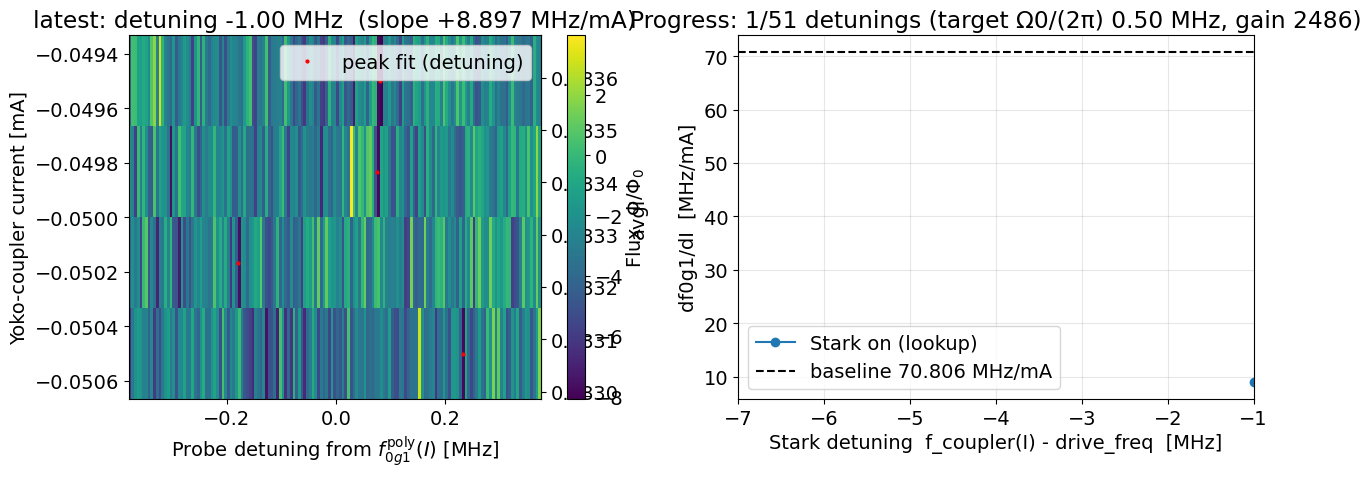

Fixed-drive Stark sweep at det -1.120 MHz, anchor I = -0.0500 mA  ->  drive_freq = 4686.927 MHz
  4 points, I in [-0.0505, -0.0495] mA
  File: D:\experiments\260420_T2_AC_stark\data\00000_PulseProbeF0g1StarkAlwaysOn_lookup_fixedDrive_det-1.12MHz_currentsweep.h5
  [1/4] I = -0.0495 mA  f0g1 = 1977.667 MHz  (drive fixed @ 4686.927 MHz)
Job submitted: JOB-20260515-00311 (queue position: 1)

[0.2s] Job JOB-20260515-00311: pending

[2.2s] Job JOB-20260515-00311: running
[WORKER] Loading PulseProbeF0g1StarkAlwaysOnExperiment from experiments.single_qubit.pulse_probe_f0g1_spectroscopy_stark
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260515-00311_PulseProbeF0g1StarkAlwaysOnExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to -0.0495mA according to expt.cfg...
[WORKER] Done setting coupler current
[PulseProbeF0g1StarkAlwaysOn] drive_hold_time = 47.25 us  (estimate 42.25 + margin 5.00)
  breakdown [us]: guard_pre=20.0, prepulse=0.00, qubit_

In [ ]:
from IPython.display import clear_output, display

# Detuning grid (MHz). Pick a span and density appropriate to your drive_gain.
detunings_MHz = np.linspace(-1, -7, 11)

# DRIVE_GAIN, RISE_TIME, STARK_GUARD_PRE, STARK_GUARD_POST, DRIVE_HOLD_MARGIN
# are defined in Step 3 (shared by Step 3 and Step 4).

FIT_CHANNEL = 'avgi'
FIT_SIGN    = 1

stark_runs       = []
stark_slopes     = []
stark_intercepts = []
stark_2d_cache   = []   # (freqs, currents, sig_2d, peaks) per detuning, kept for quick re-plot

plt.close('all')

for k, det in enumerate(detunings_MHz):
    # Inner helper's own live_plot is OFF -- the outer-loop figure below owns the display.
    run = do_f0g1_stark_current_sweep_at_detuning_with_lookup(
        station,
        detuning_MHz=float(det),
        f_coupler_func=f_coupler_func,
        f0g1_func=f0g1_func,
        currents_mA=currents_mA,
        track_drive=False,        # <-- lock the drive
        I_anchor_mA=I_set_mA,     # <-- required when track_drive=False
        live_plot=False,
        transition='f0-g1',
        drive_gain=DRIVE_GAIN,
        rise_time=RISE_TIME,
        stark_guard_pre=STARK_GUARD_PRE,
        stark_guard_post=STARK_GUARD_POST,
        drive_hold_margin=DRIVE_HOLD_MARGIN,
        start=None,
        step=0.005,
        expts=151,
        gain=100,
        length=20.0,
        reps=500,
        rounds=1,
    )

    stark_runs.append(run)

    currents_run = np.asarray(run.data['coupler_current_sweep_mA'])
    freqs_2d     = np.asarray(run.data['xpts'])
    sig_2d       = np.asarray(run.data[FIT_CHANNEL])
    f0g1_used    = np.asarray(run.data['f0g1_used_MHz'])
    peaks        = fit_peak_per_row(freqs_2d, np.abs(sig_2d), sign=FIT_SIGN)
    slope, intercept = linear_sensitivity(currents_run, peaks)
    stark_slopes.append(slope)
    stark_intercepts.append(intercept)
    stark_2d_cache.append((freqs_2d, currents_run, sig_2d, peaks, f0g1_used))
    print(f'  detuning {det:+.2f} MHz  -> dsddsafasdfzxcvf0g1/dI = {slope:.4f} MHz/mA')

    # ---- Per-detuning 2D map (logged separately, not displayed) ----
    fig_map, axes_map = plt.subplots(1, 2, figsize=(13, 5))

    detuning_2d = freqs_2d - f0g1_used[:, None]
    detuning_axis = detuning_2d[0]
    pcm = axes_map[0].pcolormesh(detuning_axis, currents_run, sig_2d,
                                 shading='nearest', cmap='viridis')
    axes_map[0].plot(peaks - f0g1_used, currents_run, 'r.', ms=4,
                     label='peak fit (detuning)')
    axes_map[0].set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
    axes_map[0].set_ylabel('Yoko-coupler current [mA]')
    axes_map[0].secondary_yaxis('right',
                                functions=(current_to_flux, flux_to_current)).set_ylabel(
        r'Flux  $\Phi/\Phi_0$')
    axes_map[0].set_title(f'f0g1 spec vs flux  (Stark detuning {det:+.2f} MHz)')
    axes_map[0].legend(loc='best')
    fig_map.colorbar(pcm, ax=axes_map[0], label=FIT_CHANNEL)

    I_dense = np.linspace(currents_run.min(), currents_run.max(), 200)
    axes_map[1].plot(currents_run, peaks, 'o', label='peak fits')
    axes_map[1].plot(I_dense, slope * I_dense + intercept, '-',
                     label=f'linear fit  slope = {slope:.4f} MHz/mA')
    axes_map[1].set_xlabel('Yoko-coupler current [mA]')
    axes_map[1].set_ylabel('f0g1 peak frequency [MHz]')
    axes_map[1].secondary_xaxis('top',
                                functions=(current_to_flux, flux_to_current)).set_xlabel(
        r'Flux  $\Phi/\Phi_0$')
    axes_map[1].set_title(f'detuning {det:+.2f} MHz  ->  df0g1/dI = {slope:.3f} MHz/mA')
    axes_map[1].legend()
    axes_map[1].grid(True, alpha=0.3)

    plt.tight_layout()

    station.log_measurement(
        fig=fig_map,
        title=f'f0g1 vs flux at Stark detuning {det:+.2f} MHz (lookup-driven)',
        project='QEC',
        parameters={
            'detuning_MHz':          float(det),
            'detuning_convention':   'f_coupler_minus_drive',
            'drive_gain':            int(DRIVE_GAIN),
            'target_Omega0_MHz':     float(TARGET_OMEGA0_MHz),
            'k_per_DAC':             float(cal['k_per_DAC']),
            'k_regime':              str(cal['regime']),
            'k_t_eff_us':            cal['t_eff_us'],
            'k_lookup_I_mA':         float(cal['I_lookup_mA']),
            'rise_time_us':          float(RISE_TIME),
            'stark_guard_pre_us':    float(STARK_GUARD_PRE),
            'stark_guard_post_us':   float(STARK_GUARD_POST),
            'drive_hold_margin_us':  float(DRIVE_HOLD_MARGIN),
            'I_set_mA':              float(I_set_mA),
            'I_span_mA':             float(I_span_mA),
            'phi_set_phi0':          float(phi_set_phi0),
            'phi_span_phi0':         float(phi_span_phi0),
            'I_npts':                int(I_npts),
            'fit_channel':           FIT_CHANNEL,
            'fit_sign':              FIT_SIGN,
            'slope_MHz_per_mA':      float(slope),
            'intercept_MHz':         float(intercept),
            'f_coupler_poly_coeffs': list(map(float, f_coupler_func.coefficients)),
            'f0g1_poly_coeffs':      list(map(float, f0g1_func.coefficients)),
            'f0g1_fit_deg':          int(F0G1_FIT_DEG),
            'f0g1_seed_source':      'f0g1_coarse',
            'lookup_pickle_path':    str(LOOKUP_PATH),
            'lookup_pickle_mtime':   float(os.path.getmtime(LOOKUP_PATH)),
        },
        data_path=run.fname,
        notes=(f'2D f0g1-vs-flux at Stark detuning {det:+.2f} MHz. '
               f'DRIVE_GAIN = {DRIVE_GAIN} chosen for Ω0/(2π) target = {TARGET_OMEGA0_MHz:.3f} MHz '
               f'via {cal["regime"]} k_per_DAC at I = {cal["I_lookup_mA"]:+.4f} mA. '
               'Per-current f0g1_freq AND drive_freq retuned from coupler_lookup_tables.pkl.'),
    )
    plt.close(fig_map)

    # ---- Live progress figure: latest 2D map + running df0g1/dI vs detuning ----
    clear_output(wait=True)
    fig_live, axes_live = plt.subplots(1, 2, figsize=(13, 5))

    pcm = axes_live[0].pcolormesh(detuning_axis, currents_run, sig_2d,
                                  shading='nearest', cmap='viridis')
    axes_live[0].plot(peaks - f0g1_used, currents_run, 'r.', ms=4,
                      label='peak fit (detuning)')
    axes_live[0].set_xlabel(r'Probe detuning from $f_{0g1}^{\rm poly}(I)$ [MHz]')
    axes_live[0].set_ylabel('Yoko-coupler current [mA]')
    axes_live[0].secondary_yaxis('right',
                                 functions=(current_to_flux, flux_to_current)).set_ylabel(
        r'Flux  $\Phi/\Phi_0$')
    axes_live[0].set_title(f'latest: detuning {det:+.2f} MHz  '
                           f'(slope {slope:+.3f} MHz/mA)')
    axes_live[0].legend(loc='best')
    fig_live.colorbar(pcm, ax=axes_live[0], label=FIT_CHANNEL)

    n_done = len(stark_slopes)
    axes_live[1].plot(detunings_MHz[:n_done], stark_slopes, 'o-', label='Stark on (lookup)')
    axes_live[1].axhline(slope_baseline, color='k', ls='--',
                         label=f'baseline {slope_baseline:.3f} MHz/mA')
    axes_live[1].set_xlim(detunings_MHz.min(), detunings_MHz.max())
    axes_live[1].set_xlabel('Stark detuning  f_coupler(I) - drive_freq  [MHz]')
    axes_live[1].set_ylabel('df0g1/dI  [MHz/mA]')
    axes_live[1].set_title(f'Progress: {n_done}/{len(detunings_MHz)} detunings '
                           f'(target Ω0/(2π) {TARGET_OMEGA0_MHz:.2f} MHz, gain {DRIVE_GAIN})')
    axes_live[1].legend(loc='best')
    axes_live[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

stark_slopes     = np.asarray(stark_slopes)
stark_intercepts = np.asarray(stark_intercepts)


## Final summary: df0g1/dI vs Stark detuning

In [ ]:
slope_baseline_per_phi0 = slope_baseline / PHI0_PER_MA            # MHz/Φ₀
stark_slopes_per_phi0   = np.asarray(stark_slopes) / PHI0_PER_MA  # MHz/Φ₀
flux_step_phi0          = phi_span_phi0 / (I_npts - 1)            # Φ₀ per step

# Estimated Ω0/(2π) [MHz] that DRIVE_GAIN actually drives, using cal @ I_set_mA.
# User convention HR = ... + Ω0*(b + b†): the stored k_per_DAC (MHz/DAC, same
# units in both regimes) equals Ω_R/(2π) per DAC, and Ω0 = Ω_R/2.
Omega0_est_MHz = cal['k_per_DAC'] * DRIVE_GAIN / 2

# Step 3 (fixed-drive) result -- single point, plotted at FIXED_DETUNING_MHz.
has_fixed_drive = 'slope_fixed_drive' in dir() and np.isfinite(slope_fixed_drive)
if has_fixed_drive:
    slope_fixed_drive_per_phi0 = slope_fixed_drive / PHI0_PER_MA

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(detunings_MHz, stark_slopes_per_phi0, 'o-', color='C0',
        label='Step 4 -- drive tracks coupler')
ax.axhline(slope_baseline_per_phi0, color='k', ls='--',
           label=f'Step 2 baseline {slope_baseline_per_phi0:+.3f} MHz/Φ₀')
if has_fixed_drive:
    ax.plot([FIXED_DETUNING_MHz], [slope_fixed_drive_per_phi0], 's', ms=10,
            color='C3',
            label=f'Step 3 fixed drive @ Δ={FIXED_DETUNING_MHz:+.2f} MHz: '
                  f'{slope_fixed_drive_per_phi0:+.3f} MHz/Φ₀')
ax.legend()
ax.set_xlabel('Stark detuning  f_coupler(I) - drive_freq  [MHz]')
ax.set_ylabel('df0g1 / dΦ  [MHz/Φ₀]')
ax.set_title(
    f'f0g1 flux sensitivity vs Stark detuning\n'
    f'Ω0/(2π) ≈ {Omega0_est_MHz:.2f} MHz   '
    f'Φ_set = {phi_set_phi0:+.3f} Φ₀   '
    f'flux step = {flux_step_phi0:.2e} Φ₀'
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

_summary_params = {
    'detunings_MHz': list(map(float, detunings_MHz)),
        'detuning_convention':   'f_coupler_minus_drive',
    'drive_gain': DRIVE_GAIN,
    'Omega0_est_MHz': float(Omega0_est_MHz),
    'rise_time_us': RISE_TIME,
    'I_set_mA':      float(I_set_mA),
    'I_span_mA':     float(I_span_mA),
    'phi_set_phi0':  float(phi_set_phi0),
    'phi_span_phi0': float(phi_span_phi0),
    'I_npts': int(I_npts),
    'fit_channel': FIT_CHANNEL,
    'fit_sign': FIT_SIGN,
    'stark_slopes_MHz_per_mA':   stark_slopes.tolist(),
    'stark_slopes_MHz_per_phi0': stark_slopes_per_phi0.tolist(),
    'stark_intercepts_MHz':      stark_intercepts.tolist(),
    'slope_baseline_MHz_per_mA':   float(slope_baseline),
    'slope_baseline_MHz_per_phi0': float(slope_baseline_per_phi0),
    'flux_step_phi0':              float(flux_step_phi0),
    'f_coupler_poly_coeffs': list(map(float, f_coupler_func.coefficients)),
    'f0g1_fine_poly_coeffs': list(map(float, f0g1_fine_func.coefficients)),
    'lookup_pickle_path': str(LOOKUP_PATH),
    'lookup_pickle_mtime': float(os.path.getmtime(LOOKUP_PATH)),
    'flux_anchors': {
        'I_PHI0_MA': float(I_PHI0_MA),
        'I_PHI_HALF_MA': float(I_PHI_HALF_MA),
        'PHI0_PER_MA': float(PHI0_PER_MA),
    },
}
if has_fixed_drive:
    _summary_params['fixed_detuning_MHz'] = float(FIXED_DETUNING_MHz)
    _summary_params['slope_fixed_drive_MHz_per_mA']   = float(slope_fixed_drive)
    _summary_params['slope_fixed_drive_MHz_per_phi0'] = float(slope_fixed_drive_per_phi0)
    _summary_params['intercept_fixed_drive_MHz']      = float(intercept_fixed_drive)
    _summary_params['drive_freq_fixed_MHz']           = float(fixed_drive_freq_MHz)

_summary_data_paths = [f0g1_baseline.fname, *(r.fname for r in stark_runs)]
if has_fixed_drive:
    _summary_data_paths.insert(1, f0g1_fixed_drive.fname)

station.log_measurement(
    fig=fig,
    title='f0g1 flux sensitivity vs Stark detuning (lookup-driven)',
    project='QEC',
    parameters=_summary_params,
    data_path=_summary_data_paths,
    notes=('Lookup-driven f0g1 flux sensitivity vs Stark detuning. '
           'Per-current f0g1_freq AND drive_freq retuned from coupler_lookup_tables.pkl '
           '(Step 4). Step 3 single-point overlay uses a drive frequency LOCKED at '
           'f_coupler(I_set) + FIXED_DETUNING_MHz (no per-current retune).'),
)


## Save aggregated results pickle

Snapshot of everything needed to redo the analysis offline. Includes the lookup pickle path + mtime so you can detect after the fact whether the lookup was rebuilt mid-experiment, and the flux anchors so the Φ axis is reproducible.

In [ ]:
results = {
    # Sweep grid + flux anchors
    'sweep_units':   SWEEP_UNITS,
    'sweep_summary': sweep_summary,
    'I_set_mA':      float(I_set_mA),
    'I_span_mA':     float(I_span_mA),
    'phi_set_phi0':  float(phi_set_phi0),
    'phi_span_phi0': float(phi_span_phi0),
    'I_npts':        int(I_npts),
    'currents_mA':   currents_mA,
    'fluxes_phi0':   fluxes_phi0,
    'flux_anchors': {
        'I_PHI0_MA':     float(I_PHI0_MA),
        'I_PHI_HALF_MA': float(I_PHI_HALF_MA),
        'PHI0_PER_MA':   float(PHI0_PER_MA),
    },
    # Lookup provenance
    'lookup_pickle_path':    str(LOOKUP_PATH),
    'lookup_pickle_mtime':   float(os.path.getmtime(LOOKUP_PATH)),
    'f_coupler_poly_coeffs': np.asarray(f_coupler_func.coefficients, dtype=float),
    'f0g1_poly_coeffs':            np.asarray(f0g1_func.coefficients, dtype=float),
    'f0g1_fit_deg':                int(F0G1_FIT_DEG),
    'f0g1_seed_source':            'f0g1_coarse',
    'f0g1_coarse_seed_I_mA':       np.asarray(f0g1_coarse_seed_I_mA, dtype=float),
    'f0g1_coarse_seed_peaks_MHz':  np.asarray(f0g1_coarse_seed_peaks, dtype=float),
    'f0g1_fine_poly_coeffs_stored': np.asarray(f0g1_fine_func.coefficients, dtype=float),
    # Step 2 (baseline)
    'baseline_currents_mA':   baseline_currents_mA,
    'baseline_freqs_MHz':     baseline_freqs_MHz,
    'baseline_sig_2d':        baseline_sig_2d,
    'baseline_f0g1_used_MHz': baseline_f0g1_used,
    'baseline_peaks_MHz':     peaks_baseline,
    'slope_baseline':         float(slope_baseline),
    'intercept_baseline':     float(intercept_baseline),
    'baseline_fname':         f0g1_baseline.fname,
    # Step 3 (single-detuning fixed-drive Stark sweep)
    'fixed_detuning_MHz':         float(FIXED_DETUNING_MHz),
    'fixed_drive_freq_MHz':       float(fixed_drive_freq_MHz),
    'fixed_drive_currents_mA':    fixed_drive_currents_mA,
    'fixed_drive_freqs_2d':       fixed_drive_freqs_2d,
    'fixed_drive_sig_2d':         fixed_drive_sig_2d,
    'fixed_drive_f0g1_used_MHz':  fixed_drive_f0g1_used,
    'fixed_drive_peaks_MHz':      peaks_fixed_drive,
    'slope_fixed_drive':          float(slope_fixed_drive),
    'intercept_fixed_drive':      float(intercept_fixed_drive),
    'fixed_drive_fname':          f0g1_fixed_drive.fname,
    # Step 4 (Stark detuning sweep)
    'detunings_MHz':          np.asarray(detunings_MHz, dtype=float),
    'drive_gain':             int(DRIVE_GAIN),
    'rise_time_us':           float(RISE_TIME),
    'slopes_per_detuning':    np.asarray(stark_slopes, dtype=float),
    'intercepts_per_detuning': np.asarray(stark_intercepts, dtype=float),
    'stark_run_fnames':       [r.fname for r in stark_runs],
}

out_path = Path(station.data_path) / 'f0g1_stark_flux_sensitivity_lookup_results.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(results, f)
print(f'Saved results to {out_path}')
